# Realized Volatility Timing — Rendu projet

## Vue d'ensemble du projet

Ce notebook implémente un système de **timing de volatilité** en deux parties :

### Partie 1 — Backtest de stratégies optionnelles avec delta/gamma hedging
- Génération de positions via `OptionTrade`, `DeltaHedgedOptionTrade`, `DeltaGammaHedgedOptionTrade`
- Backtest P&L décomposé (delta, gamma, theta, vega, résiduel)
- Comparaison avec/sans coûts de transaction (`BacktesterBidAskFromData`, `BacktesterFixedRelativeBidAsk`)

### Partie 2 — Nowcasting de la volatilité réalisée par Filtre de Kalman non-linéaire (UKF)
- Modèle de Heston en espace d'état sur les log-returns
- Unscented Kalman Filter avec correction exacte de la corrélation ρ
- Construction du spread s_t = σ_IV,t − σ̂_t
- Allocation dynamique des stratégies de carry vol selon s_t

### Dynamique de Heston (modèle continu)

$$\begin{cases}
dS_t = \mu S_t \, dt + S_t \sqrt{v_t} \, dW_{1,t} \\
dv_t = \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_{2,t} \\
dW_{1,t} \cdot dW_{2,t} = \rho \, dt
\end{cases}$$

- $v_t$ est la **variance latente** (état caché)
- $S_t$ est le **prix spot observé** (observation)
- L'objectif est d'estimer $\hat{v}_t$ pour en déduire $\hat{\sigma}_t = \sqrt{\hat{v}_t}$
- Puis calculer le spread $s_t = \sigma_{IV,t} - \hat{\sigma}_t$ pour le timing

## 0 — Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Stratégie de vol\Realized-Volatility-Timing


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
print(sys.path[0])

/Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing


In [4]:
import logging
import warnings

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc("font", **{"size": 16})
print(sys.path[0])

2026-03-24 18:39:21,287 | INFO | Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2026-03-24 18:39:21,289 | INFO | NumExpr defaulting to 8 threads.


c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Stratégie de vol\Realized-Volatility-Timing


In [5]:
#pip install filterpy

In [6]:
# Imports investment_lab
from investment_lab.data.option_db import OptionLoader, SPYOptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.rates import compute_forward
from investment_lab.metrics.volatility import rolling_realized_volatility
from investment_lab.metrics.util import levels_to_returns
from investment_lab.metrics.performance import sharpe_ratio, max_drawdown, calmar_ratio
from investment_lab import option_strategies

# Classes de backtest et de trading
from investment_lab.option_trade import (
    OptionTrade,
    DeltaHedgedOptionTrade,
    DeltaGammaHedgedOptionTrade,
)
from investment_lab.backtest import (
    StrategyBacktester,
    BacktesterBidAskFromData,
    BacktesterFixedRelativeBidAsk,
)

# UKF Heston
from investment_lab.heston_ukf import (
    HestonParams,
    HestonUKF,
    VolatilityTiming,
    build_timing_positions,
)



In [7]:
# ── Paramètres globaux ──────────────────────────────────────────────────────
START = datetime(2020, 1, 2)
END   = datetime(2022, 12, 30)
TICKER = "SPY"

print(f"Période : {START.date()} → {END.date()} | Ticker : {TICKER}")

Période : 2020-01-02 → 2022-12-30 | Ticker : SPY


---
## Partie 1 — Backtest de stratégies optionnelles

### 1.1 Génération des trades — Stratégie de base (Short Strangle 95/105, 1W)

On commence par la stratégie de carry vol la plus simple : vente d'un strangle
hebdomadaire 95%/105% (short put K=95%, short call K=105%, maturité 1 semaine).

Le `OptionTrade.generate_trades()` retourne un DataFrame de positions journalières
avec les colonnes : `[date, option_id, entry_date, leg_name, weight, ticker]`.

In [8]:
# Génération des positions pour le short strangle 95/105 1W
# Rebalancement chaque mercredi (rebal_week_day=[0,2,4] dans la définition de la stratégie)
df_base = OptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

print(f"Positions générées : {len(df_base):,} lignes")
print(f"Dates : {df_base['date'].min().date()} → {df_base['date'].max().date()}")
df_base.head(10)

2026-03-25 11:11:13,481 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-03-25 11:11:13,482 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:11:18,750 | INFO | Processing with {'ticker': 'SPY'}
2026-03-25 11:11:18,751 | INFO | Potentially add extra field with None
2026-03-25 11:11:26,495 | INFO | Preprocessing option data.
2026-03-25 11:11:26,496 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-03-25 11:11:28,182 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-03-25 11:11:29,750 | INFO | Converting 898 df_trades to daily time series
2026-03-25 11:11:34,651 | INFO | Forward filling option data for df
2026-03-25 11:11:35,483 

Positions générées : 5,390 lignes
Dates : 2020-01-03 → 2022-12-30


,date,option_id,entry_date,leg_name,weight,ticker
0,2020-01-03,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
1,2020-01-03,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
2,2020-01-06,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
3,2020-01-06,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
4,2020-01-06,SPY 20200113C340,2020-01-06,Short K=105% Call 1W,-0.000515,SPY
5,2020-01-06,SPY 20200113P307,2020-01-06,Short K=95% Put 1W,-0.000515,SPY
6,2020-01-07,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
7,2020-01-07,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
8,2020-01-07,SPY 20200113C340,2020-01-06,Short K=105% Call 1W,-0.000515,SPY
9,2020-01-07,SPY 20200113P307,2020-01-06,Short K=95% Put 1W,-0.000515,SPY


### 1.2 Backtest sans coûts de transaction

Le `StrategyBacktester` décompose le P&L en composantes grecques :
- **delta_pnl** = w × ΔS × δ_{t-1}
- **gamma_pnl** = ½ × w × ΔS² × γ_{t-1}
- **theta_pnl** = w × Δt × θ_{t-1}
- **vega_pnl**  = w × Δσ × ν_{t-1}
- **residual_pnl** = pnl total − somme des grecques

In [9]:
# Backtest sans coûts de transaction
bt_base = StrategyBacktester(df_base).compute_backtest()

2026-03-25 11:11:44,697 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 11:11:44,700 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:11:49,196 | INFO | Processing with {'ticker': ['SPY']}
2026-03-25 11:11:49,197 | INFO | Potentially add extra field with None
2026-03-25 11:12:02,585 | INFO | Forward filling option data for df
2026-03-25 11:12:03,441 | INFO | Aucun coût de transaction appliqué.
2026-03-25 11:12:03,501 | INFO | Computing period to period difference, for P&L calculations.
2026-03-25 11:12:03,511 | INFO | Append previous period greeks for P&L calculations.
2026-03-25 11:12:03,594 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:07<00:00, 101.14it/s]
2026-03-25 11:12:11,401 | INFO | Backtest computation completed.


In [10]:
# ── Métriques de performance ────────────────────────────────────────────────
rets_base = bt_base.nav["NAV"].pct_change().dropna()

print("=== Short Strangle 95/105 1W — Sans coûts de transaction ===")
print(f"  Sharpe Ratio     : {sharpe_ratio(rets_base):.2f}")
print(f"  Max Drawdown     : {max_drawdown(rets_base)*100:.1f}%")
print(f"  Calmar Ratio     : {calmar_ratio(rets_base):.2f}")

=== Short Strangle 95/105 1W — Sans coûts de transaction ===
  Sharpe Ratio     : 0.25
  Max Drawdown     : -6.3%
  Calmar Ratio     : 0.16


### Commentaire d'analyse
Le short strangle non couvert présente un profil de performance positif mais modeste. Un `Sharpe` de `0.25` indique que la prime captée existe, mais qu'elle reste faible une fois rapportée à la volatilité de la stratégie. Le `max drawdown` de `-6.3%` rappelle que l'exposition short vol reste sensible aux épisodes de stress, en particulier lorsque les mouvements du sous-jacent deviennent brusques.

Économiquement, cette première lecture est cohérente avec une stratégie qui encaisse du portage en régime normal mais subit des pertes asymétriques lors des hausses de volatilité. Cette version de base sert donc surtout de point de comparaison pour évaluer si le hedge ou le timing améliorent réellement le couple rendement-risque.


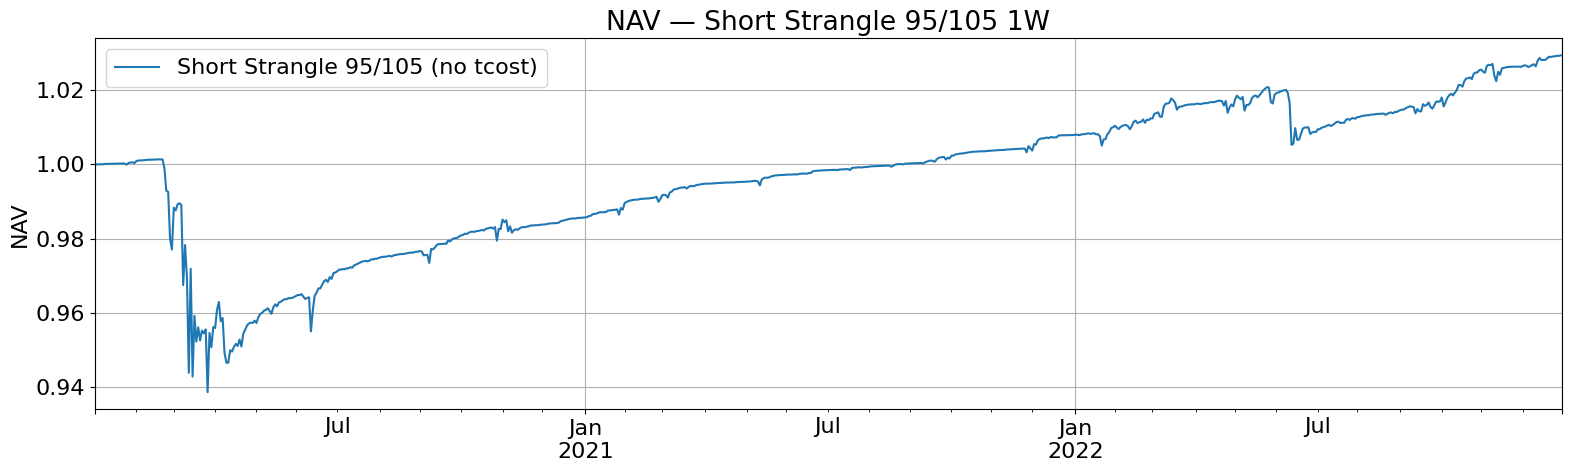

In [11]:
# ── NAV ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bt_base.nav["NAV"].plot(ax=ax, label="Short Strangle 95/105 (no tcost)", grid=True)
ax.set_title("NAV — Short Strangle 95/105 1W")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()

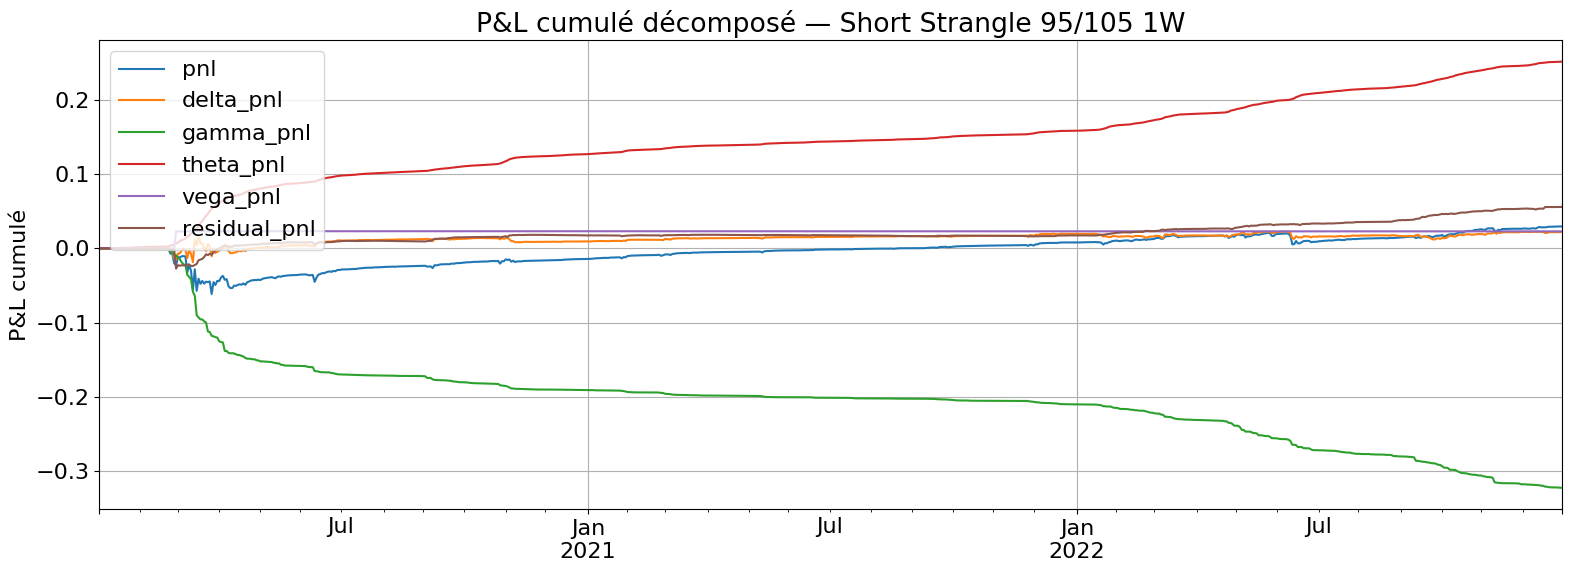

In [12]:
# ── Décomposition P&L cumulé ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
bt_base.pnl.cumsum().plot(ax=ax, grid=True)
ax.set_title("P&L cumulé décomposé — Short Strangle 95/105 1W")
ax.set_ylabel("P&L cumulé")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 1.3 Impact des coûts de transaction

On compare trois modèles de coûts :
1. **Sans coût** — mid price utilisé partout
2. **Bid/Ask réel** — bid à l'entrée pour les shorts, ask à la sortie (et inversement pour les longs)
3. **Spread fixe 3%** — demi-spread de 3% du mid appliqué à chaque transaction

In [13]:
# Backtest avec bid/ask réel
bt_datatcost = BacktesterBidAskFromData(df_base).compute_backtest()

# Backtest avec spread fixe de 3%
bt_fixed3 = BacktesterFixedRelativeBidAsk(df_base).compute_backtest(
    tcost_args={"relative_half_spread": 0.03}
)

2026-03-25 11:12:12,496 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 11:12:12,498 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:12:17,146 | INFO | Processing with {'ticker': ['SPY']}
2026-03-25 11:12:17,147 | INFO | Potentially add extra field with None
2026-03-25 11:12:28,111 | INFO | Forward filling option data for df
2026-03-25 11:12:29,011 | INFO | Application du spread bid/ask observé aux dates de transaction.
2026-03-25 11:12:29,076 | INFO | Computing period to period difference, for P&L calculations.
2026-03-25 11:12:29,084 | INFO | Append previous period greeks for P&L calculations.
2026-03-25 11:12:29,168 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:07<00:00, 100.35it/s]
2026-03-25 11:12:36,957 | INFO | Backtest computation completed.
2026-03-25 11:12:37,180 | INFO | Chargement des données d’options pour la pério

In [14]:
# ── Tableau comparatif ──────────────────────────────────────────────────────
results = []
for name, bt in [
    ("No transaction cost",       bt_base),
    ("Bid-Ask from data",          bt_datatcost),
    ("Fixed 3% half-spread",       bt_fixed3),
]:
    rets = bt.nav["NAV"].pct_change().dropna()
    results.append({
        "Strategy": name,
        "Sharpe":   round(sharpe_ratio(rets), 2),
        "Max DD (%)": round(max_drawdown(rets) * 100, 1),
        "Calmar":   round(calmar_ratio(rets), 2),
    })

pd.DataFrame(results).set_index("Strategy")

,Sharpe,Max DD (%),Calmar
Strategy,,,
No transaction cost,0.25,-6.3,0.16
Bid-Ask from data,0.21,-6.4,0.14
Fixed 3% half-spread,0.15,-6.7,0.09


### Commentaire d'analyse
L'ajout de coûts de transaction dégrade immédiatement les métriques. Le passage de `0.25` à `0.21`, puis à `0.15` de Sharpe, montre qu'une part importante de la performance brute provient d'un edge relativement fin, facilement absorbé par les frictions d'exécution.

Le message économique est important : sur des options courtes maturités, le turnover est élevé et les spreads comptent. Une stratégie crédible doit donc rester défendable après coûts, sinon sa profitabilité est surtout théorique.


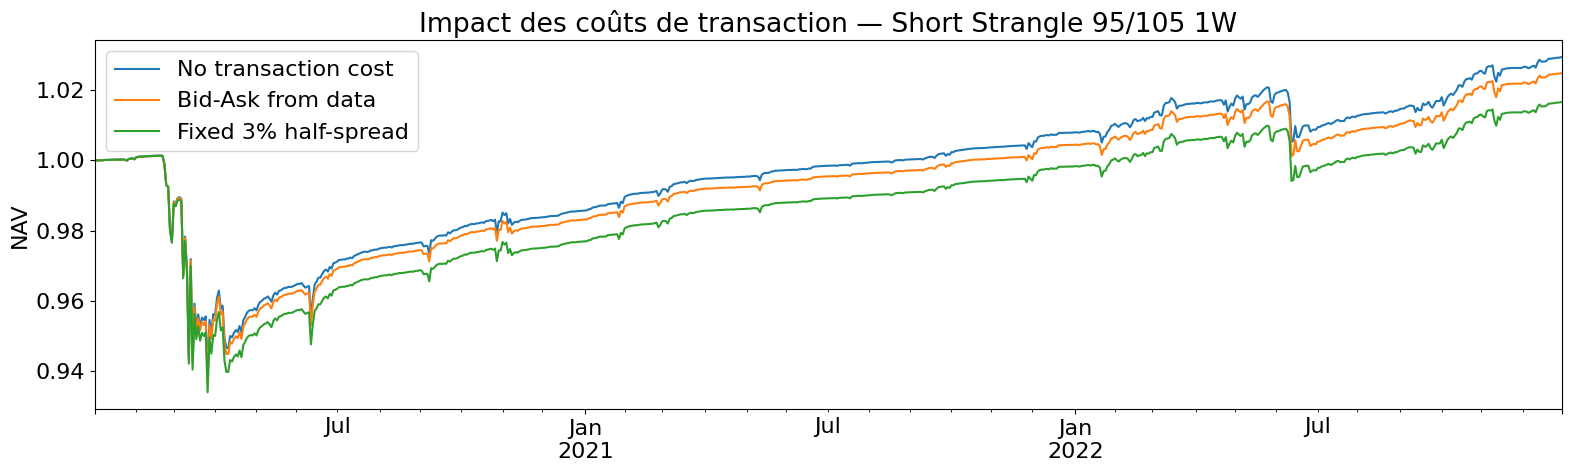

In [15]:
# ── Comparaison NAV ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bt_base.nav["NAV"].plot(ax=ax,      label="No transaction cost", grid=True)
bt_datatcost.nav["NAV"].plot(ax=ax, label="Bid-Ask from data")
bt_fixed3.nav["NAV"].plot(ax=ax,    label="Fixed 3% half-spread")
ax.set_title("Impact des coûts de transaction — Short Strangle 95/105 1W")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()

### 1.4 Delta Hedging

Le `DeltaHedgedOptionTrade` ajoute une jambe de couverture delta quotidienne.
Pour chaque groupe (date, ticker, entry_date), il calcule le delta net du portefeuille
et l'annule via une position spot dont l'expiration est fixée au maximum des
expirations des jambes d'options (correction vs l'implémentation originale).

L'effet attendu : réduction de la sensibilité directionnelle, isolement du P&L vega/gamma.

In [16]:
# Génération des positions avec delta hedging
df_dh = DeltaHedgedOptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

print(f"Positions avec delta hedge : {len(df_dh):,} lignes")
print(f"Jambes : {df_dh['leg_name'].unique().tolist()}")

2026-03-25 11:13:03,033 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-03-25 11:13:03,034 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:13:07,378 | INFO | Processing with {'ticker': 'SPY'}
2026-03-25 11:13:07,378 | INFO | Potentially add extra field with None
2026-03-25 11:13:14,794 | INFO | Preprocessing option data.
2026-03-25 11:13:14,795 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-03-25 11:13:16,393 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-03-25 11:13:17,965 | INFO | Converting 898 df_trades to daily time series
2026-03-25 11:13:22,484 | INFO | Forward filling option data for df
2026-03-25 11:13:23,139 

Positions avec delta hedge : 8,085 lignes
Jambes : ['DELTA_HEDGING', 'Short K=105% Call 1W', 'Short K=95% Put 1W']


In [17]:
# Backtest delta-hedgé
bt_dh = StrategyBacktester(df_dh).compute_backtest()

2026-03-25 11:13:31,779 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 11:13:31,782 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None


2026-03-25 11:13:35,893 | INFO | Processing with {'ticker': ['SPY']}
2026-03-25 11:13:35,894 | INFO | Potentially add extra field with None
2026-03-25 11:13:46,496 | INFO | Forward filling option data for df
2026-03-25 11:13:47,434 | INFO | Aucun coût de transaction appliqué.
2026-03-25 11:13:47,498 | INFO | Computing period to period difference, for P&L calculations.
2026-03-25 11:13:47,506 | INFO | Append previous period greeks for P&L calculations.
2026-03-25 11:13:47,627 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:07<00:00, 103.52it/s]
2026-03-25 11:13:55,177 | INFO | Backtest computation completed.


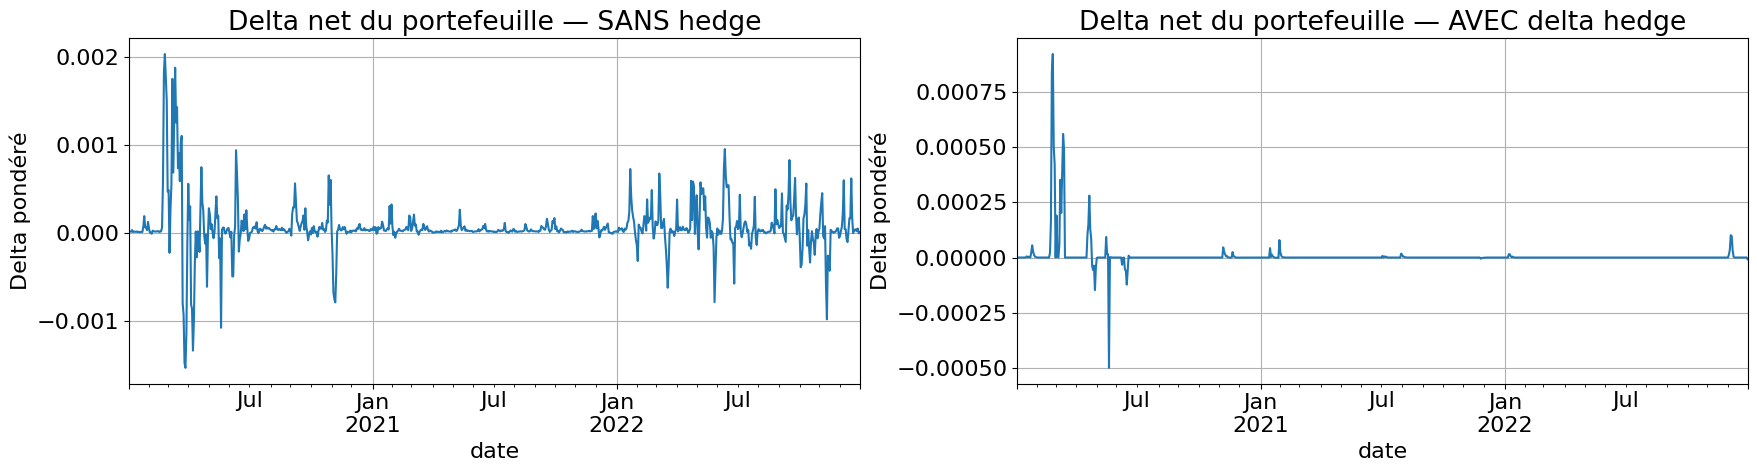

In [18]:
# ── Vérification : delta portefeuille avant/après hedge ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Delta pondéré sans hedge
df_nd = bt_base.drifted_positions.copy()
df_nd["wgt_delta"] = df_nd["delta"] * df_nd["scaled_weight"]
df_nd.groupby("date")["wgt_delta"].sum().plot(ax=ax1, grid=True,
    title="Delta net du portefeuille — SANS hedge", ylabel="Delta pondéré")

# Delta pondéré avec hedge
df_dh_pos = bt_dh.drifted_positions.copy()
df_dh_pos["wgt_delta"] = df_dh_pos["delta"] * df_dh_pos["scaled_weight"]
df_dh_pos.groupby("date")["wgt_delta"].sum().plot(ax=ax2, grid=True,
    title="Delta net du portefeuille — AVEC delta hedge", ylabel="Delta pondéré")

plt.tight_layout()
plt.show()

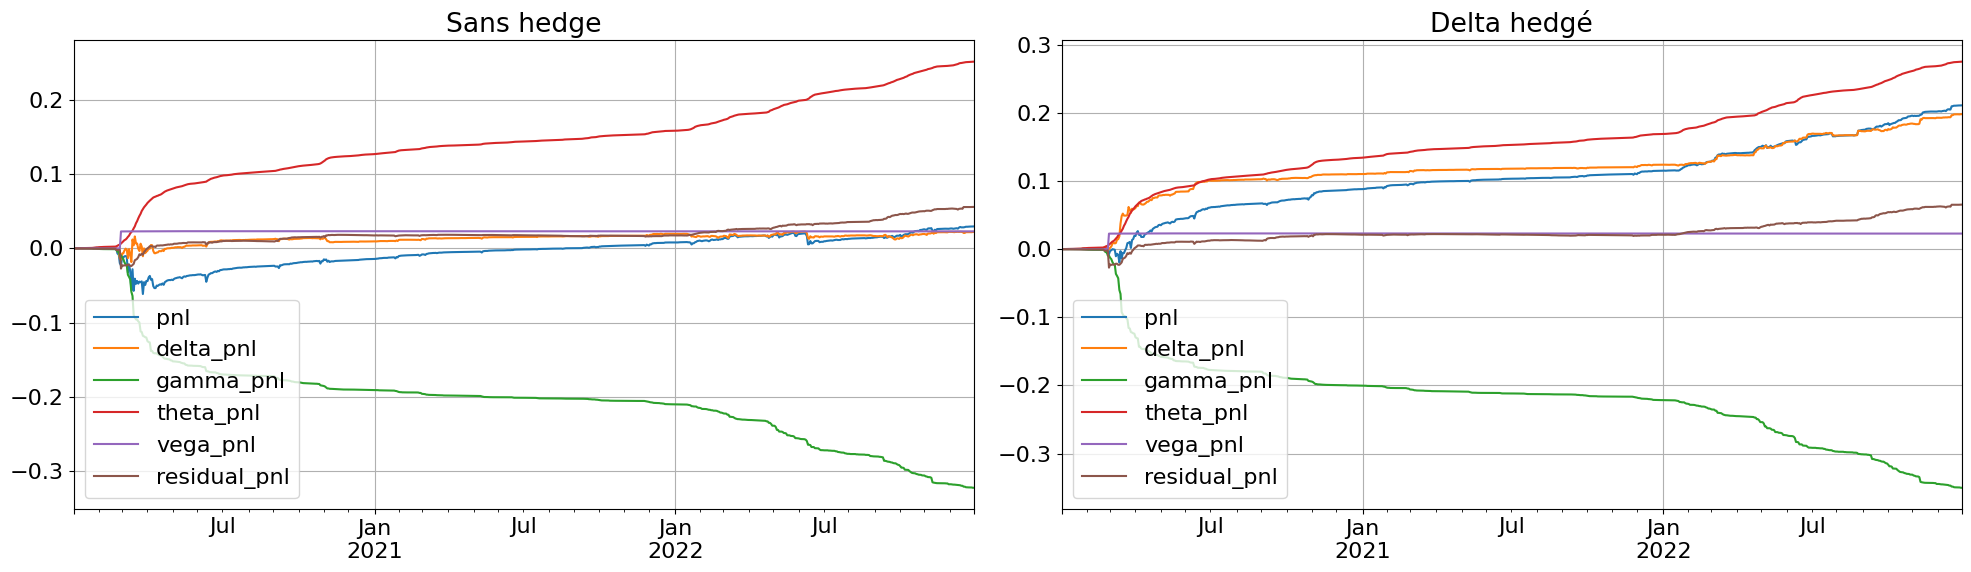

In [19]:
# ── Comparaison P&L décomposé : sans hedge vs delta-hedgé ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
bt_base.pnl.cumsum().plot(ax=ax1, title="Sans hedge", grid=True)
bt_dh.pnl.cumsum().plot(ax=ax2, title="Delta hedgé", grid=True)
plt.tight_layout()
plt.show()

### 1.5 Delta-Gamma Hedging

Le `DeltaGammaHedgedOptionTrade` ajoute d'abord une jambe d'option longue
pour couvrir le gamma (réduire la convexité du portefeuille), puis neutralise
le delta résultant via une couverture spot.

In [20]:
# La jambe de couverture gamma : long put 10D 5 jours
GAMMA_HEDGE_LEG = {
    "day_to_expiry_target": 5,
    "strike_target": -0.1,
    "strike_col": "delta",
    "call_or_put": "P",
    "weight": 0.2,
    "leg_name": "Long 10D Put 5d",
    "rebal_week_day": [2],
}

df_dgh = DeltaGammaHedgedOptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
    hedging_args={"hedging_leg": GAMMA_HEDGE_LEG},
)

print(f"Jambes présentes : {df_dgh['leg_name'].unique().tolist()}")

2026-03-25 11:13:56,756 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-03-25 11:13:56,758 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:14:00,909 | INFO | Processing with {'ticker': 'SPY'}
2026-03-25 11:14:00,910 | INFO | Potentially add extra field with None
2026-03-25 11:14:07,633 | INFO | Preprocessing option data.
2026-03-25 11:14:07,634 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-03-25 11:14:09,369 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-03-25 11:14:11,147 | INFO | Converting 898 df_trades to daily time series
2026-03-25 11:14:16,105 | INFO | Forward filling option data for df
2026-03-25 11:14:16,866 

Jambes présentes : ['DELTA_HEDGING', 'Short K=105% Call 1W', 'Short K=95% Put 1W', 'Long 10D Put 5d']


In [21]:
# Backtest delta-gamma hedgé
bt_dgh = StrategyBacktester(df_dgh).compute_backtest()

2026-03-25 11:14:41,876 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 11:14:41,879 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None


2026-03-25 11:14:45,820 | INFO | Processing with {'ticker': ['SPY']}
2026-03-25 11:14:45,821 | INFO | Potentially add extra field with None
2026-03-25 11:14:56,631 | INFO | Forward filling option data for df
2026-03-25 11:14:57,598 | INFO | Aucun coût de transaction appliqué.
2026-03-25 11:14:57,663 | INFO | Computing period to period difference, for P&L calculations.
2026-03-25 11:14:57,671 | INFO | Append previous period greeks for P&L calculations.
2026-03-25 11:14:57,874 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:07<00:00, 101.31it/s]
2026-03-25 11:15:05,588 | INFO | Backtest computation completed.


In [22]:
# ── Tableau de synthèse Partie 1 ────────────────────────────────────────────
results_p1 = []
for name, bt in [
    ("Base (no hedge)",           bt_base),
    ("Delta hedged",               bt_dh),
    ("Delta-Gamma hedged",         bt_dgh),
    ("Base + data tcost",          bt_datatcost),
    ("Base + fixed 3% tcost",      bt_fixed3),
]:
    rets = bt.nav["NAV"].pct_change().dropna()
    results_p1.append({
        "Strategy": name,
        "Sharpe":    round(sharpe_ratio(rets), 2),
        "Max DD (%)": round(max_drawdown(rets) * 100, 1),
        "Calmar":    round(calmar_ratio(rets), 2),
    })

pd.DataFrame(results_p1).set_index("Strategy")

,Sharpe,Max DD (%),Calmar
Strategy,,,
Base (no hedge),0.25,-6.3,0.16
Delta hedged,2.77,-2.1,2.94
Delta-Gamma hedged,3.19,-1.7,3.60
Base + data tcost,0.21,-6.4,0.14
Base + fixed 3% tcost,0.15,-6.7,0.09


### Commentaire d'analyse
Cette table est le résultat central de la partie 1. Le `delta hedge` améliore très fortement le profil de la stratégie, avec une hausse marquée du Sharpe et une réduction nette du drawdown. Le `delta-gamma hedge` va encore un peu plus loin, ce qui suggère que la stratégie brute mélangeait plusieurs expositions : directionnelle, convexité et portage de volatilité.

Une fois ces expositions mieux neutralisées, la stratégie ressemble davantage à une extraction plus propre de prime de volatilité. C'est une conclusion économiquement forte : dans ce notebook, l'amélioration la plus convaincante vient du hedging, beaucoup plus que du timing.


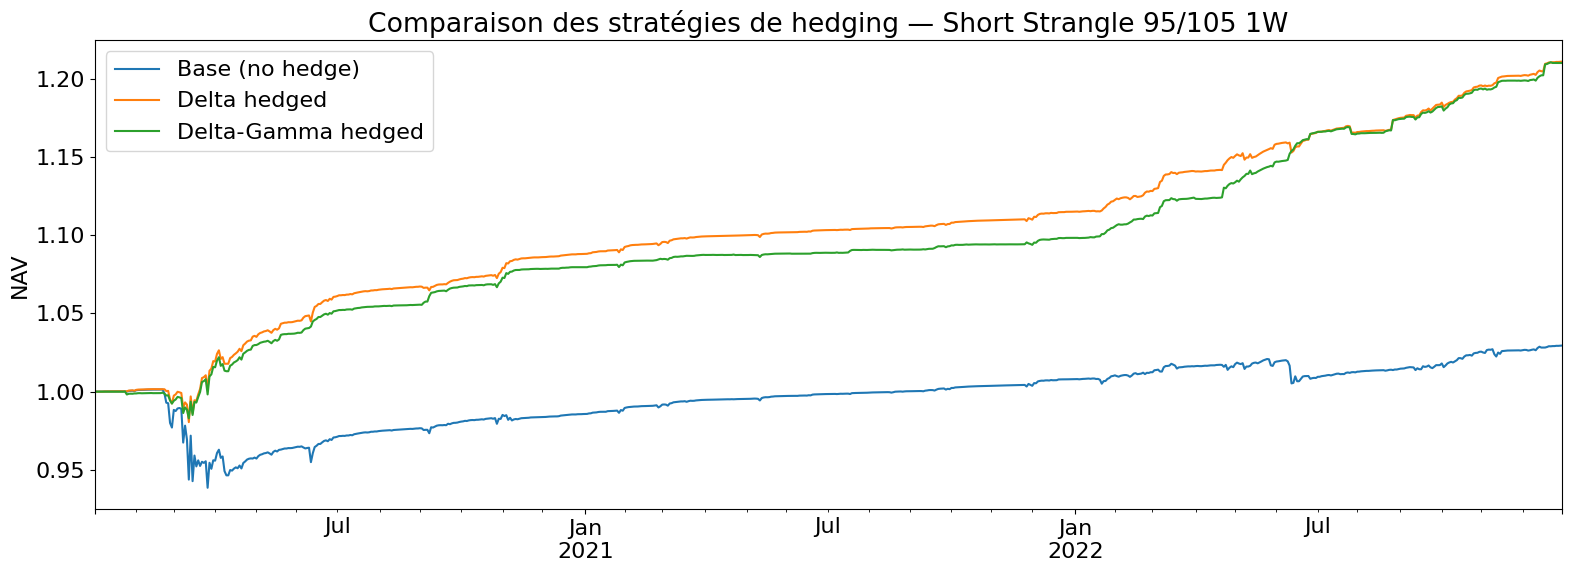

In [23]:
# ── Comparaison NAV ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
bt_base.nav["NAV"].plot(ax=ax,  label="Base (no hedge)",        grid=True)
bt_dh.nav["NAV"].plot(ax=ax,    label="Delta hedged")
bt_dgh.nav["NAV"].plot(ax=ax,   label="Delta-Gamma hedged")
ax.set_title("Comparaison des stratégies de hedging — Short Strangle 95/105 1W")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()

---
## Partie 2 — Nowcasting de la volatilité réalisée par UKF (dynamique de Heston)

### 2.1 Modèle en espace d'état et discrétisation

Le modèle de Heston est reformulé comme un **State Space Model (SSM)** :

**Équation d'état** (variance latente $v_t$) :
$$v_{t+1} = v_t + \kappa(\theta - v_t)\Delta t + \xi\sqrt{v_t}\sqrt{\Delta t}\,\varepsilon_t^{(2)}$$
$$\text{Bruit de processus : } Q_t = \xi^2 v_t \Delta t$$

**Équation d'observation** (log-return $r_t$ via formule d'Itô) :
$$r_t = \left(\mu - \frac{v_t}{2}\right)\Delta t + \sqrt{v_t \Delta t}\,\varepsilon_t^{(1)}$$
$$\text{Bruit de mesure : } R_t = v_t \Delta t$$

**Terme de corrélation** (spécifique à Heston, absent de filterpy standard) :
$$P_{xz} = \text{Cov}(v_{t+1}, r_t) = \rho \cdot \xi \cdot v_t \cdot \Delta t$$

Ce terme est injecté manuellement dans `HestonUKFCore.update()` avant le calcul
du gain de Kalman $K = P_{xz} \cdot S^{-1}$.

### 2.2 Chargement des données et préparation

In [24]:
# Chargement des données options et spot SPY
df_options = OptionLoader.load_data(START, END, process_kwargs={"ticker": TICKER})
df_spot = extract_spot_from_options(df_options)
df_rates = USRatesLoader.load_data(START, END)
df_options = compute_forward(df_options=df_options, df_rates=df_rates)

print(f"Options chargées : {len(df_options):,} lignes")
print(f"Dates : {df_options['date'].min().date()} → {df_options['date'].max().date()}")

2026-03-25 11:15:06,428 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:15:10,911 | INFO | Processing with {'ticker': 'SPY'}
2026-03-25 11:15:10,912 | INFO | Potentially add extra field with None
2026-03-25 11:15:19,273 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-03-25 11:15:19,340 | INFO | Processing with None
2026-03-25 11:15:19,341 | INFO | Potentially add extra field with None


Options chargées : 7,178,158 lignes
Dates : 2020-01-02 → 2022-12-30


Log-returns : 757 observations
Moyenne : 0.0003 | Std : 0.0159


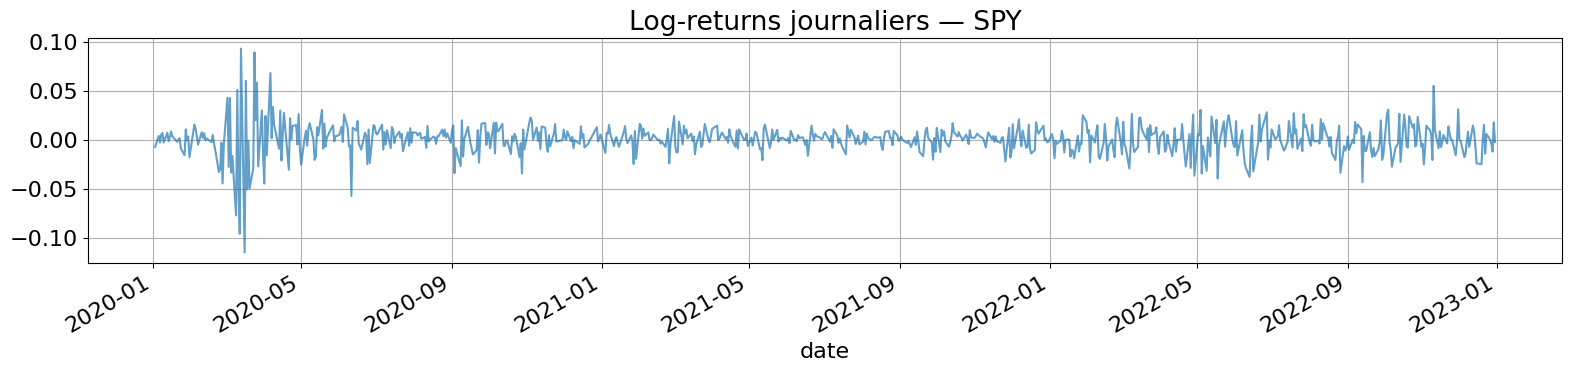

In [25]:
# ── Log-returns journaliers depuis le spot ───────────────────────────────────
# levels_to_returns calcule log(S_t / S_{t-1})
log_returns = levels_to_returns(df_spot.set_index("date")["spot"], method="log")
log_returns = log_returns.dropna()

print(f"Log-returns : {len(log_returns)} observations")
print(f"Moyenne : {log_returns.mean():.4f} | Std : {log_returns.std():.4f}")

fig, ax = plt.subplots(figsize=(16, 4))
log_returns.plot(ax=ax, grid=True, title="Log-returns journaliers — SPY", alpha=0.7)
plt.tight_layout()
plt.show()

### Commentaire d'analyse
Les log-returns journaliers du spot servent ici de base à la calibration et au filtrage Heston-UKF. L'écart-type journalier observé est cohérent avec un actif actions large cap sur une période incluant des épisodes de stress importants.

Cette série est centrale pour tout ce qui suit : si le modèle reconstruit mal la dynamique de variance à partir de ces rendements, alors le spread IV-RV et le signal de timing seront mécaniquement fragilisés.


In [26]:
# ── Volatilité implicite ATM (sigma_IV) ─────────────────────────────────────
# On sélectionne l'option ATM à la monnaie (moneyness ≈ 1) et maturité ~1 mois
from investment_lab.option_selection import select_options

df_atm = select_options(
    df_options,
    call_or_put="C",
    strike_col="moneyness",
    strike_target=1.0,
    day_to_expiry_target=30,
)

# sigma_IV = série temporelle de la vol implicite ATM annualisée
sigma_iv = df_atm.set_index("date")["implied_volatility"]

print(f"sigma_IV : {len(sigma_iv)} dates")
print(f"Moyenne : {sigma_iv.mean():.2%} | Min : {sigma_iv.min():.2%} | Max : {sigma_iv.max():.2%}")

sigma_IV : 758 dates
Moyenne : 20.68% | Min : 9.81% | Max : 73.80%


### Commentaire d'analyse
La volatilité implicite ATM couvre une plage très large, avec un maximum élevé, ce qui reflète bien les régimes de marché extrêmes présents dans l'échantillon. La moyenne autour de `20%` donne un point de repère utile pour juger ensuite si la volatilité estimée par le modèle reste réaliste ou non.

Cette série est l'ancrage "marché" du notebook : elle représente le prix du risque de volatilité observé dans les options, que l'on cherchera ensuite à comparer à une volatilité "fondamentale" estimée par le filtre.


### 2.3 Calibration MLE rolling des paramètres de Heston

Les paramètres $(\kappa, \theta, \xi, \rho, \mu)$ sont estimés par maximum de vraisemblance sur une **fenêtre glissante** de 252 jours.
À chaque date $t$, la calibration n'utilise que l'historique passé disponible avant la date de filtrage, ce qui maintient un cadre **out-of-sample**.


In [27]:
# Calibration MLE rolling sur une fenêtre glissante de 252 jours
# Les paramètres affichés ci-dessous correspondent au dernier jeu calibré disponible.

ukf_model = HestonUKF(
    initial_params=HestonParams(kappa=2.0, theta=0.04, xi=0.3, rho=-0.7, mu=0.0),
    dt=1.0 / 252.0,
    cache_dir=".cache/heston_ukf",
)

ukf_model.fit(log_returns, window=252, use_cache=True, refit_every=5)

p = ukf_model.params
print("=== Dernier jeu de paramètres calibrés (rolling) ===")
print(f"  κ (kappa) = {p.kappa:.4f}  [vitesse mean-reversion]")
print(f"  θ (theta) = {p.theta:.4f}  [variance long terme → vol {np.sqrt(p.theta):.1%}]")
print(f"  ξ (xi)    = {p.xi:.4f}  [vol-of-vol]")
print(f"  ρ (rho)   = {p.rho:.4f}  [corrélation spot/variance]")
print(f"  μ (mu)    = {p.mu:.6f}  [drift]")
print(f"  Condition de Feller (2κθ > ξ²) : {p.feller_satisfied()}")
print(f"Première date calibrée : {ukf_model.rolling_params.index.min()}")
print(f"Dernière date calibrée : {ukf_model.rolling_params.index.max()}")


2026-03-25 11:16:57,173 | INFO | Fitting HestonUKF : n=757 observations, window=252.
2026-03-25 11:16:57,182 | INFO | Cache rolling chargé depuis .cache/heston_ukf/rolling_bff7497f09a53038c3989154f25f52192a66d323ffcd005be28a5382b533b318.pkl (505 lignes).
2026-03-25 11:16:57,432 | INFO | Reprise de la calibration rolling après 2022-12-30 00:00:00.
2026-03-25 11:16:57,435 | INFO | Calibration rolling entièrement restaurée depuis le cache.


=== Dernier jeu de paramètres calibrés (rolling) ===
  κ (kappa) = 6.2904  [vitesse mean-reversion]
  θ (theta) = 0.0477  [variance long terme → vol 21.8%]
  ξ (xi)    = 0.6278  [vol-of-vol]
  ρ (rho)   = -0.5369  [corrélation spot/variance]
  μ (mu)    = 0.003952  [drift]
  Condition de Feller (2κθ > ξ²) : True
Première date calibrée : 2021-01-07 00:00:00
Dernière date calibrée : 2022-12-30 00:00:00


### Commentaire d'analyse
Les paramètres calibrés sont globalement plausibles pour SPY : `rho` est négatif, ce qui est attendu, `theta` implique une volatilité de long terme réaliste, et la condition de Feller est satisfaite sur le dernier jeu de paramètres. Cela suggère qu'au moins en fin d'échantillon, la calibration n'est pas aberrante.

Il faut néanmoins garder à l'esprit qu'une calibration acceptable en coupe ne garantit pas une bonne stabilité temporelle. C'est précisément l'objet des diagnostics rolling qui suivent.


### 2.4 Diagnostics de calibration rolling

On inspecte ici les diagnostics de la calibration rolling :
- dates exactes de la fenêtre utilisée pour chaque fit ;
- convergence de l'optimiseur ;
- amélioration de la log-vraisemblance ;
- stabilité des paramètres dans le temps.

Point méthodologique clé : à la date de calibration $t$, la log-vraisemblance est calculée sur la fenêtre **passée** `[t-window, t)`.


Nombre de calibrations documentées : 445
Nombre de violations réelles      : 0
Aucun signe de look-ahead dans les calibrations documentées.


,value
metric,
n_fits,445.000000
optimizer_success_rate,0.934831
median_loglik_improvement,0.000000
min_loglik_improvement,0.000000
share_feller_violation,0.022472
avg_nfev,74.575281


,window_start,window_end,window_size,optimizer_success,start_loglik,final_loglik,loglik_improvement
date,,,,,,,
2021-04-06,2020-03-31,2021-04-05,252.0,True,739.827572,740.227983,0.400411
2021-04-07,2020-04-01,2021-04-06,252.0,True,740.134632,740.134632,0.000000
2021-04-08,2020-04-02,2021-04-07,252.0,True,739.848630,739.848630,0.000000
2021-04-09,2020-04-03,2021-04-08,252.0,True,743.639003,743.639003,0.000000
2021-04-12,2020-04-06,2021-04-09,252.0,True,740.522313,740.522313,0.000000
2021-04-13,2020-04-07,2021-04-12,252.0,True,755.981695,756.215319,0.233624
2021-04-14,2020-04-08,2021-04-13,252.0,True,756.077164,756.077164,0.000000
2021-04-15,2020-04-09,2021-04-14,252.0,True,759.558930,759.558930,0.000000
2021-04-16,2020-04-13,2021-04-15,252.0,True,760.242333,760.242333,0.000000


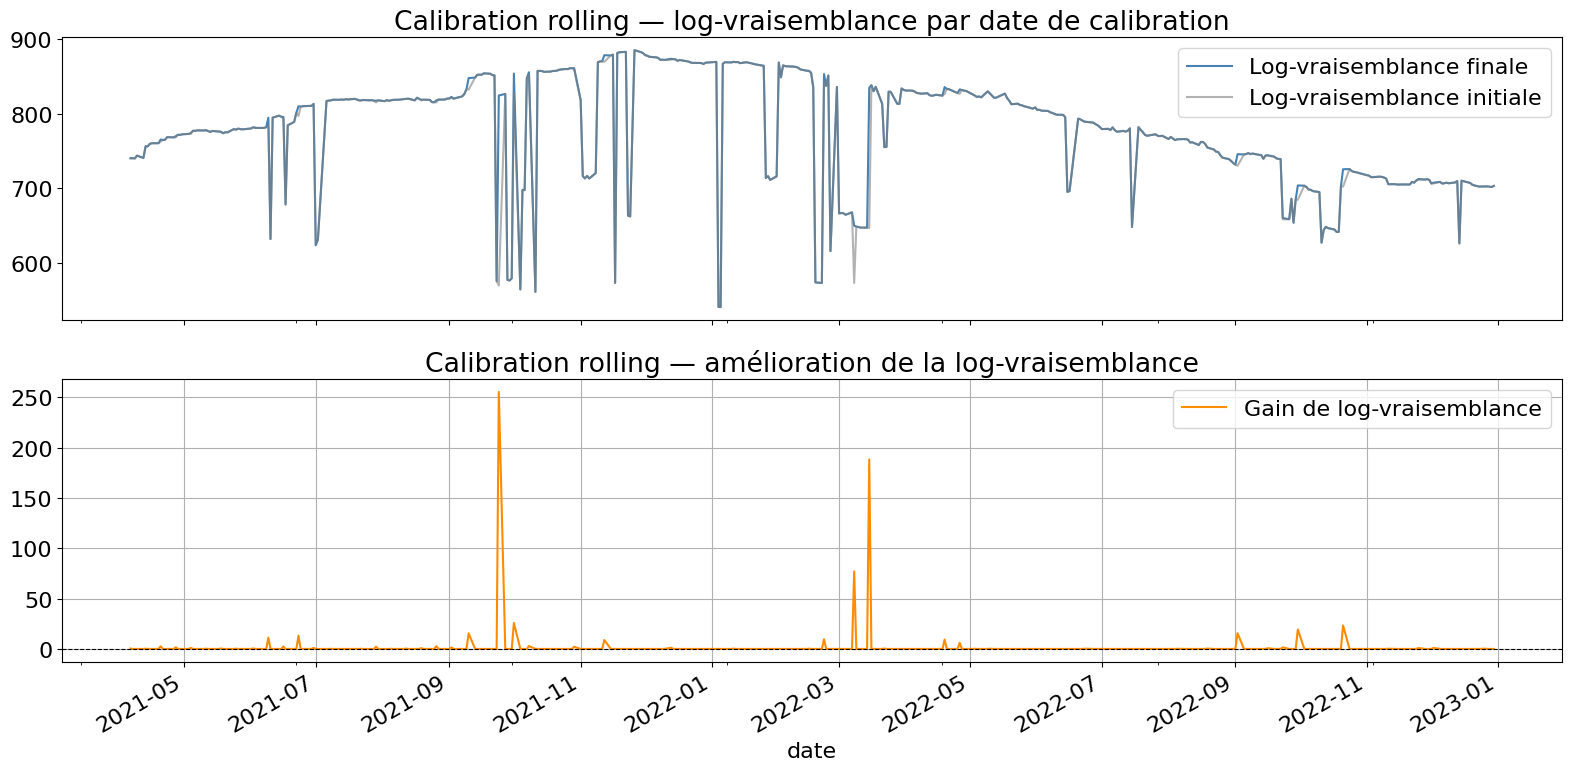

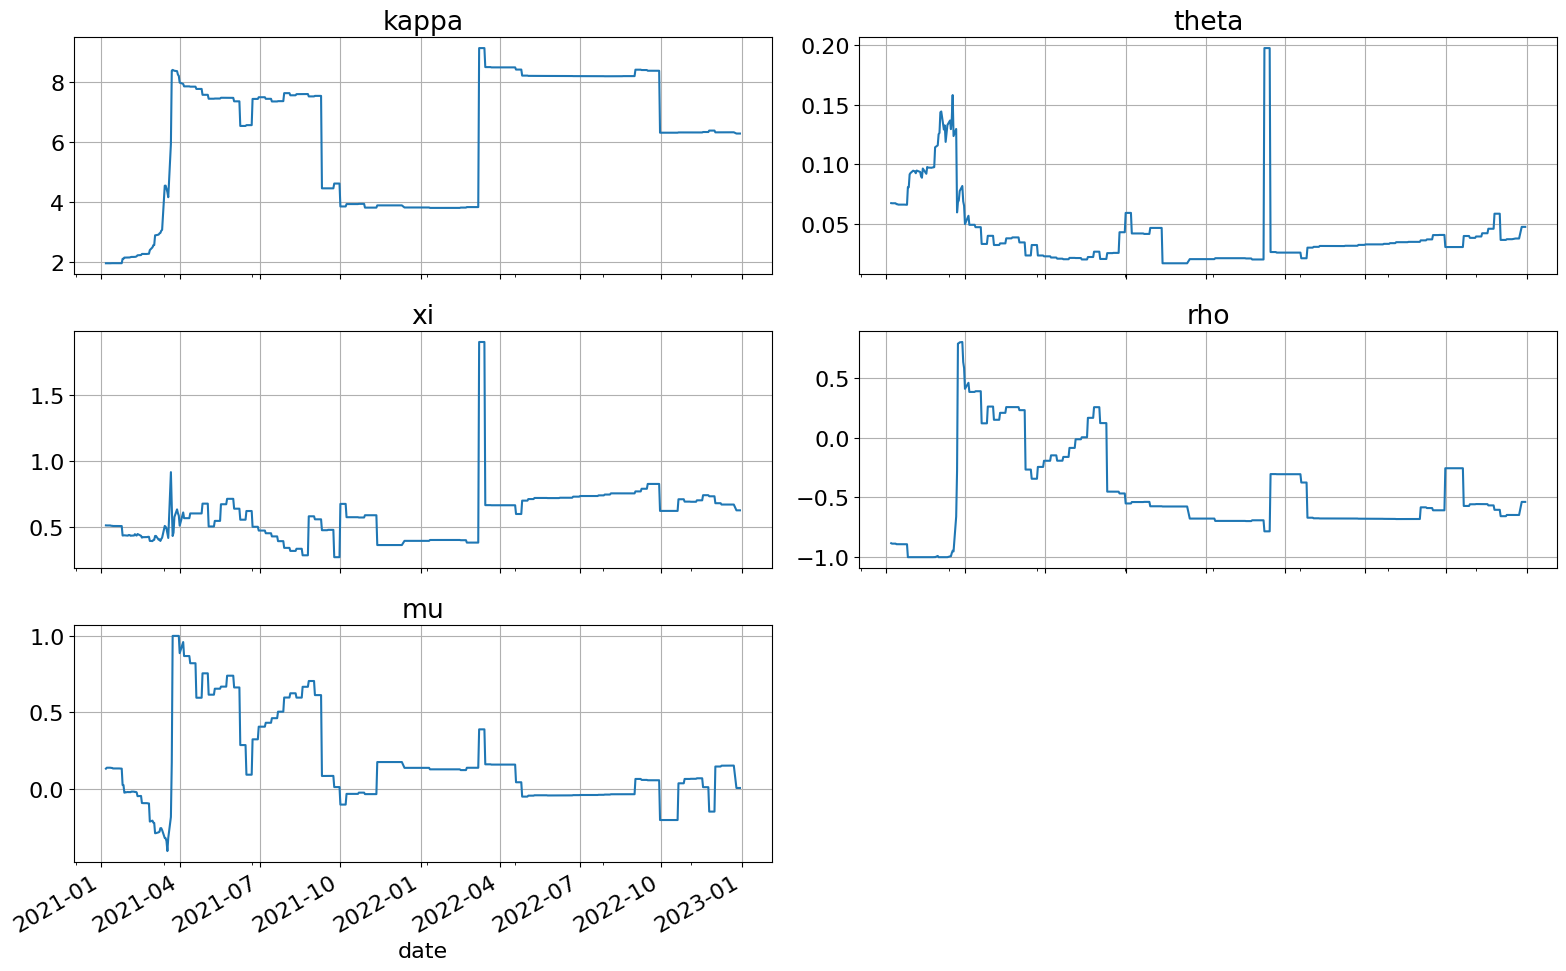

In [28]:
# ── Diagnostics de calibration rolling ────────────────────────────────────
fit_diag_raw = ukf_model.fit_diagnostics.copy()
rolling_params = ukf_model.rolling_params.copy()

# Harmonisation des types
fit_diag_raw.index = pd.to_datetime(fit_diag_raw.index)

for col in ["window_start", "window_end"]:
    if col in fit_diag_raw.columns:
        fit_diag_raw[col] = pd.to_datetime(fit_diag_raw[col], errors="coerce")

# On ne conserve que les vraies calibrations documentées
fit_diag = fit_diag_raw.dropna(subset=["window_start", "window_end", "window_size"]).copy()

# Vérification explicite : le fit daté t utilise seulement la fenêtre passée [t-window, t)
violations = fit_diag.loc[~(fit_diag.index > fit_diag["window_end"])]

print(f"Nombre de calibrations documentées : {len(fit_diag)}")
print(f"Nombre de violations réelles      : {len(violations)}")

if len(violations) > 0:
    display(violations[["window_start", "window_end", "window_size"]].head(20))
    raise AssertionError("Certaines calibrations semblent utiliser la date courante ou future.")
else:
    print("Aucun signe de look-ahead dans les calibrations documentées.")

fit_diag_summary = pd.DataFrame({
    "metric": [
        "n_fits",
        "optimizer_success_rate",
        "median_loglik_improvement",
        "min_loglik_improvement",
        "share_feller_violation",
        "avg_nfev",
    ],
    "value": [
        len(fit_diag),
        fit_diag["optimizer_success"].mean(),
        fit_diag["loglik_improvement"].median(),
        fit_diag["loglik_improvement"].min(),
        (fit_diag["feller_violation"] > 0).mean(),
        fit_diag["nfev"].mean(),
    ],
}).set_index("metric")
display(fit_diag_summary)

display(
    fit_diag[
        [
            "window_start",
            "window_end",
            "window_size",
            "optimizer_success",
            "start_loglik",
            "final_loglik",
            "loglik_improvement",
        ]
    ].head(10)
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fit_diag["final_loglik"].plot(ax=axes[0], color="steelblue", grid=True, label="Log-vraisemblance finale")
fit_diag["start_loglik"].plot(ax=axes[0], color="gray", alpha=0.6, label="Log-vraisemblance initiale")
axes[0].set_title("Calibration rolling — log-vraisemblance par date de calibration")
axes[0].legend()

fit_diag["loglik_improvement"].plot(ax=axes[1], color="darkorange", grid=True, label="Gain de log-vraisemblance")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Calibration rolling — amélioration de la log-vraisemblance")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
for ax, col in zip(axes.flatten(), ["kappa", "theta", "xi", "rho", "mu"]):
    rolling_params[col].plot(ax=ax, grid=True, title=col)
axes[-1, -1].axis("off")
plt.tight_layout()
plt.show()

### Commentaire d'analyse
Les diagnostics sont plutôt rassurants sur le plan méthodologique : le taux de succès de l'optimiseur est élevé et la vérification explicite ne détecte pas de look-ahead dans les calibrations documentées. Le cadre temporel du modèle semble donc correctement posé.

En revanche, le fait que le gain médian de log-vraisemblance soit nul indique que de nombreuses recalibrations modifient peu la qualité d'ajustement. Cela peut vouloir dire que les paramètres sont souvent recyclés d'une fenêtre à l'autre, ce qui est pratique numériquement, mais peut aussi signaler une dynamique peu informative pour construire un signal très réactif.


In [29]:
fit_diag = ukf_model.fit_diagnostics.copy()
fit_diag.index = pd.to_datetime(fit_diag.index)

for col in ["window_start", "window_end"]:
    if col in fit_diag.columns:
        fit_diag[col] = pd.to_datetime(fit_diag[col], errors="coerce")

fit_diag = fit_diag.dropna(subset=["window_start", "window_end", "window_size"]).copy()
violations = fit_diag.loc[~(fit_diag.index > fit_diag["window_end"])]

display(violations[["window_start", "window_end", "window_size"]].head(20))
print("Nombre de violations :", len(violations))


,window_start,window_end,window_size
date,,,


Nombre de violations : 0


### 2.5 Filtrage UKF — estimation de $\hat{v}_t$

Le filtre propage 3 sigma-points (Merwe α=1e-3, β=2, κ=0) à travers la dynamique
de Heston à chaque pas de temps. La correction $\rho \cdot \xi \cdot v_t \cdot \Delta t$
est injectée dans $P_{xz}$ avant le calcul du gain de Kalman.

On utilise ici `filter_with_diagnostics()` afin de conserver les innovations, la variance d'innovation et le gain de Kalman pour l'analyse.


In [30]:
# Filtrage UKF avec diagnostics complets
filter_diag = ukf_model.filter_with_diagnostics(log_returns)
v_hat = filter_diag["v_hat"]
sigma_hat = filter_diag["sigma_hat"]

print(f"v_hat estimé — Moyenne : {v_hat.mean():.4f} | Std : {v_hat.std():.4f}")
print(f"sigma_hat estimé — Moyenne : {sigma_hat.mean():.2%}")
print(f"Innovation standardisée — Moyenne : {filter_diag['std_innovation'].mean():.3f} | Std : {filter_diag['std_innovation'].std():.3f}")
print(f"Kalman gain — Moyenne : {filter_diag['kalman_gain'].mean():.4f}")


v_hat estimé — Moyenne : 0.5148 | Std : 1.3986
sigma_hat estimé — Moyenne : 43.34%
Innovation standardisée — Moyenne : -0.020 | Std : 0.845
Kalman gain — Moyenne : -0.8957


### Commentaire d'analyse
Le filtre produit une volatilité estimée moyenne sensiblement supérieure à la moyenne de volatilité implicite observée plus haut. Pris isolément, ce n'est pas impossible, mais cela attire l'attention : si `sigma_hat` est trop souvent au-dessus de `sigma_IV`, le spread IV-RV deviendra structurellement négatif et poussera le signal à réduire l'exposition short vol.

L'innovation standardisée reste globalement bien centrée, ce qui est plutôt bon signe. En revanche, l'interprétation économique finale dépend surtout de la stabilité de `v_hat` et `sigma_hat` dans le temps, ce que les figures suivantes permettent de juger.


### 2.6 Diagnostics du filtre

On vérifie que les innovations standardisées restent raisonnablement centrées et que le gain de Kalman ne présente pas de comportement explosif.


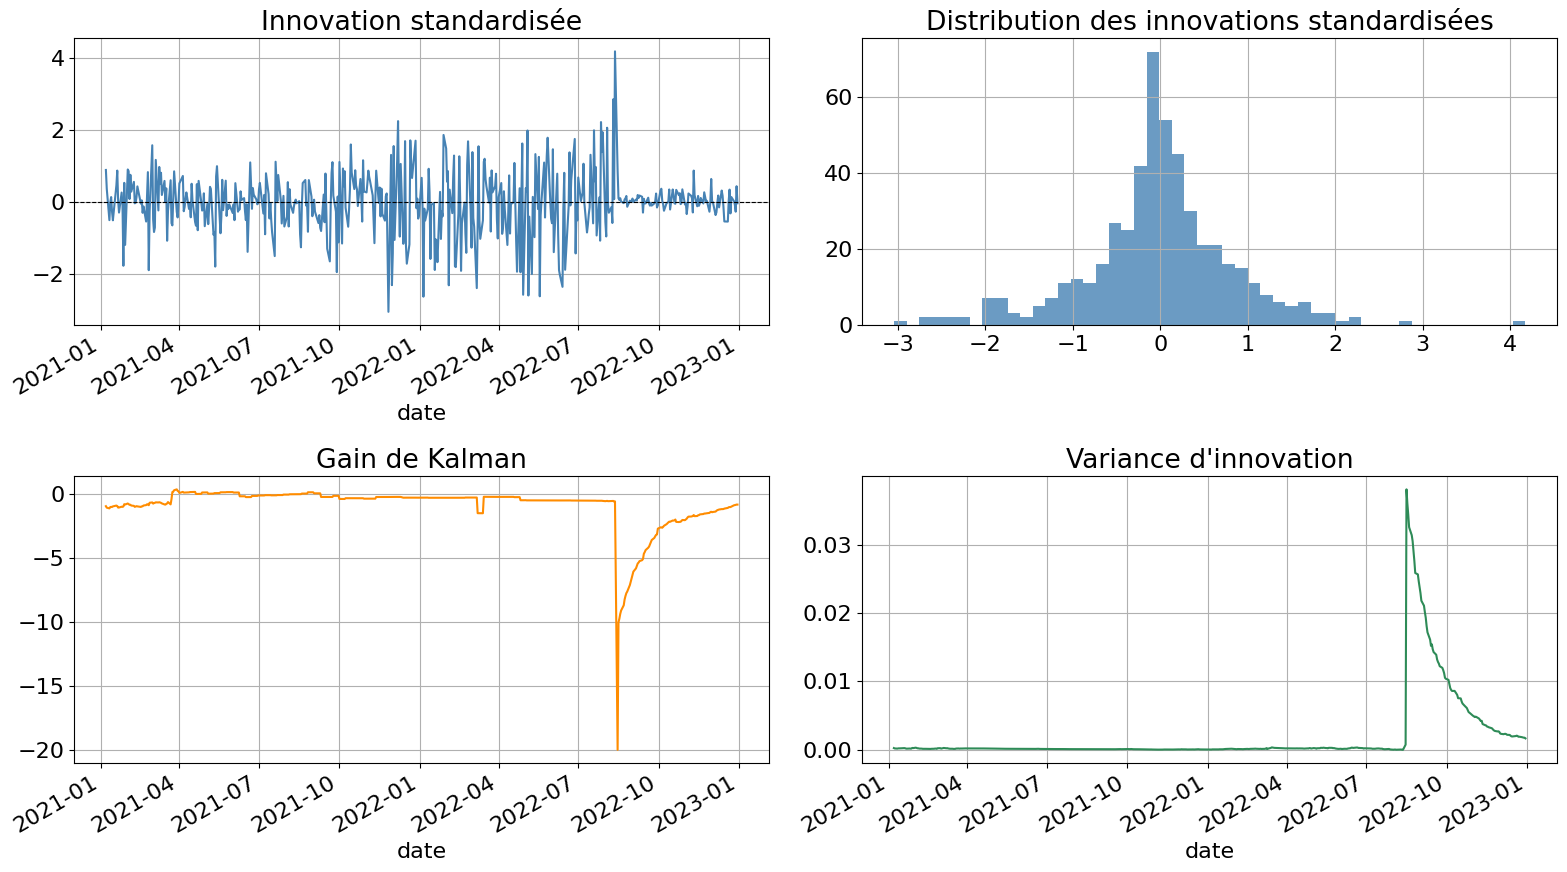

In [31]:
# ── Diagnostics du filtre UKF ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

filter_diag["std_innovation"].plot(ax=axes[0, 0], color="steelblue", grid=True)
axes[0, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Innovation standardisée")

filter_diag["std_innovation"].hist(ax=axes[0, 1], bins=50, color="steelblue", alpha=0.8)
axes[0, 1].set_title("Distribution des innovations standardisées")

filter_diag["kalman_gain"].plot(ax=axes[1, 0], color="darkorange", grid=True)
axes[1, 0].set_title("Gain de Kalman")

filter_diag[["innovation_var"]].plot(ax=axes[1, 1], color="seagreen", grid=True, legend=False)
axes[1, 1].set_title("Variance d'innovation")

plt.tight_layout()
plt.show()


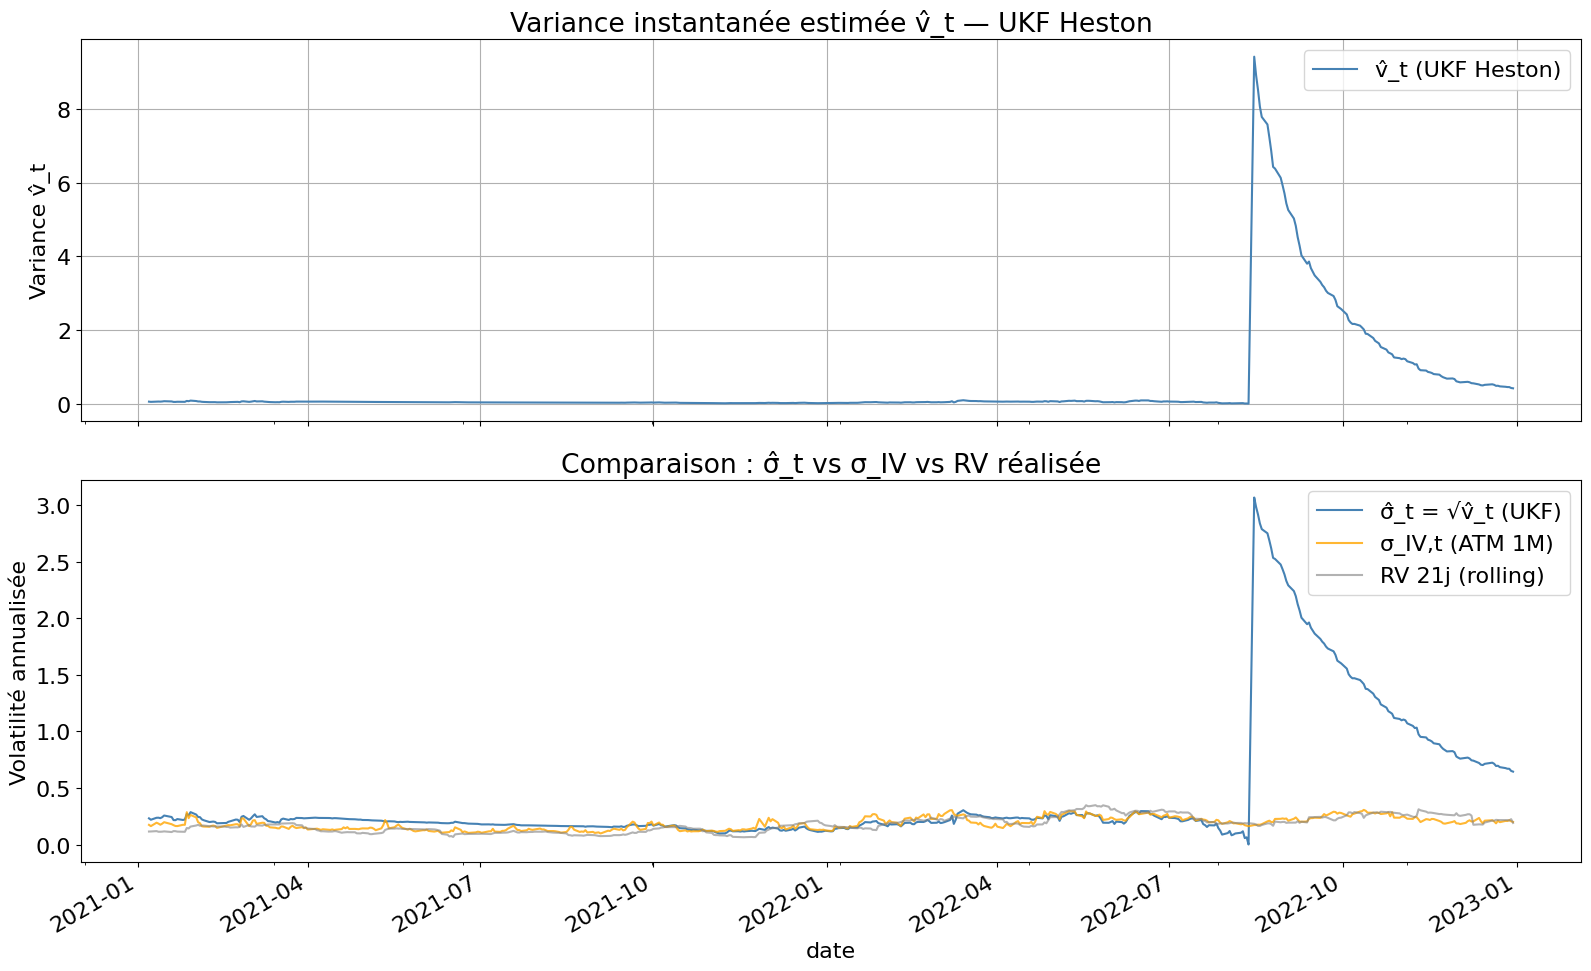

In [32]:
# ── Visualisation : v_hat et sigma_hat vs vol réalisée ───────────────────────
# Volatilité réalisée comme référence
rv_21d = rolling_realized_volatility(log_returns, window=21, volatility_type="std")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Variance filtrée
v_hat.plot(ax=ax1, label="v̂_t (UKF Heston)", color="steelblue", grid=True)
ax1.set_title("Variance instantanée estimée v̂_t — UKF Heston")
ax1.set_ylabel("Variance v̂_t")
ax1.legend()

# Volatilité estimée vs vol implicite vs vol réalisée
sigma_hat.plot(ax=ax2, label="σ̂_t = √v̂_t (UKF)", color="steelblue", grid=True)
sigma_iv.reindex(sigma_hat.index).plot(ax=ax2, label="σ_IV,t (ATM 1M)", color="orange", alpha=0.8)
rv_21d.reindex(sigma_hat.index).plot(ax=ax2, label="RV 21j (rolling)", color="gray", alpha=0.6)
ax2.set_title("Comparaison : σ̂_t vs σ_IV vs RV réalisée")
ax2.set_ylabel("Volatilité annualisée")
ax2.legend()

plt.tight_layout()
plt.show()

### 2.7 Spread IV-RV  $s_t = \sigma_{IV,t} - \hat{\sigma}_t$

Le spread mesure la **prime de risque de volatilité** estimée :
- $s_t > 0$ → IV chère par rapport à la RV estimée → carry positif → **short vol profitable**
- $s_t < 0$ → IV bon marché → RV > IV → réduire/fermer la position

Spread s_t — Moyenne : -24.63% | Std : 55.46%
% jours s_t > 0 (IV chère) : 34.1%


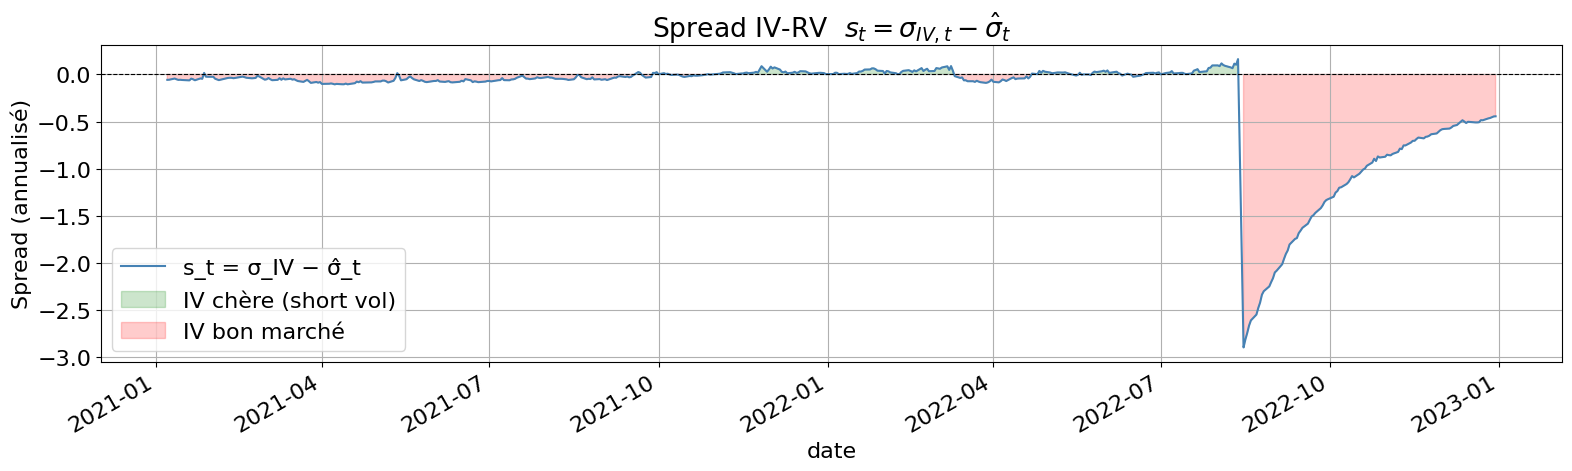

In [33]:
# Calcul du spread s_t = sigma_IV - sigma_hat
spread = ukf_model.implied_realized_spread(sigma_iv)

print(f"Spread s_t — Moyenne : {spread.mean():.2%} | Std : {spread.std():.2%}")
print(f"% jours s_t > 0 (IV chère) : {(spread > 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(16, 5))
spread.plot(ax=ax, label="s_t = σ_IV − σ̂_t", color="steelblue", grid=True)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(spread.index, spread, 0,
                where=(spread > 0), alpha=0.2, color="green",  label="IV chère (short vol)")
ax.fill_between(spread.index, spread, 0,
                where=(spread < 0), alpha=0.2, color="red",    label="IV bon marché")
ax.set_title("Spread IV-RV  $s_t = \sigma_{IV,t} - \hat{\sigma}_t$")
ax.set_ylabel("Spread (annualisé)")
ax.legend()
plt.tight_layout()
plt.show()

### Commentaire d'analyse
Le spread moyen est nettement négatif, ce qui signifie que le modèle estime en moyenne une volatilité réalisée/fondamentale supérieure à la volatilité implicite. Dans une logique de short vol, ce résultat est défavorable : le modèle dit souvent que les options ne sont pas suffisamment chères pour justifier une vente agressive de volatilité.

Le fait que seulement environ un tiers des jours aient un spread positif limite déjà le potentiel du timing. Si ce spread est en plus influencé par quelques épisodes de filtration instable, le signal final risque d'être dominé par des artefacts du modèle plutôt que par une véritable information prédictive.


### 2.8 Signal de timing et allocation dynamique

On normalise $s_t$ en un signal d'allocation $f(s_t) \in [-\text{max\_leverage}, +\text{max\_leverage}]$
puis on l'applique aux poids de la stratégie de base :
$$w_t = w_{\text{base}} \times f(s_t)$$

Trois modes de normalisation sont disponibles :
- **linear** : $f(s_t) = \text{clip}(s_t / \sigma_{s}, \pm L)$ — proportionnel au spread normalisé
- **rank** : percentile roulant recentré — robuste aux outliers  
- **threshold** : signal binaire ±1 au-delà de bandes ±seuil

Convention de backtest retenue pour éviter tout **look-ahead bias** :
- le spread $s_t$ et le signal $f(s_t)$ sont calculés avec l'information disponible à la clôture de la date $t$ ;
- ce signal n'est **pas** appliqué à la position du même jour ;
- l'exécution est décalée d'**un jour ouvré** : le poids utilisé à la date $t+1$ dépend du signal observé à la date $t$.

Autrement dit, dans le backtest, la décision exécutable au jour $t$ ne dépend jamais d'une information future.


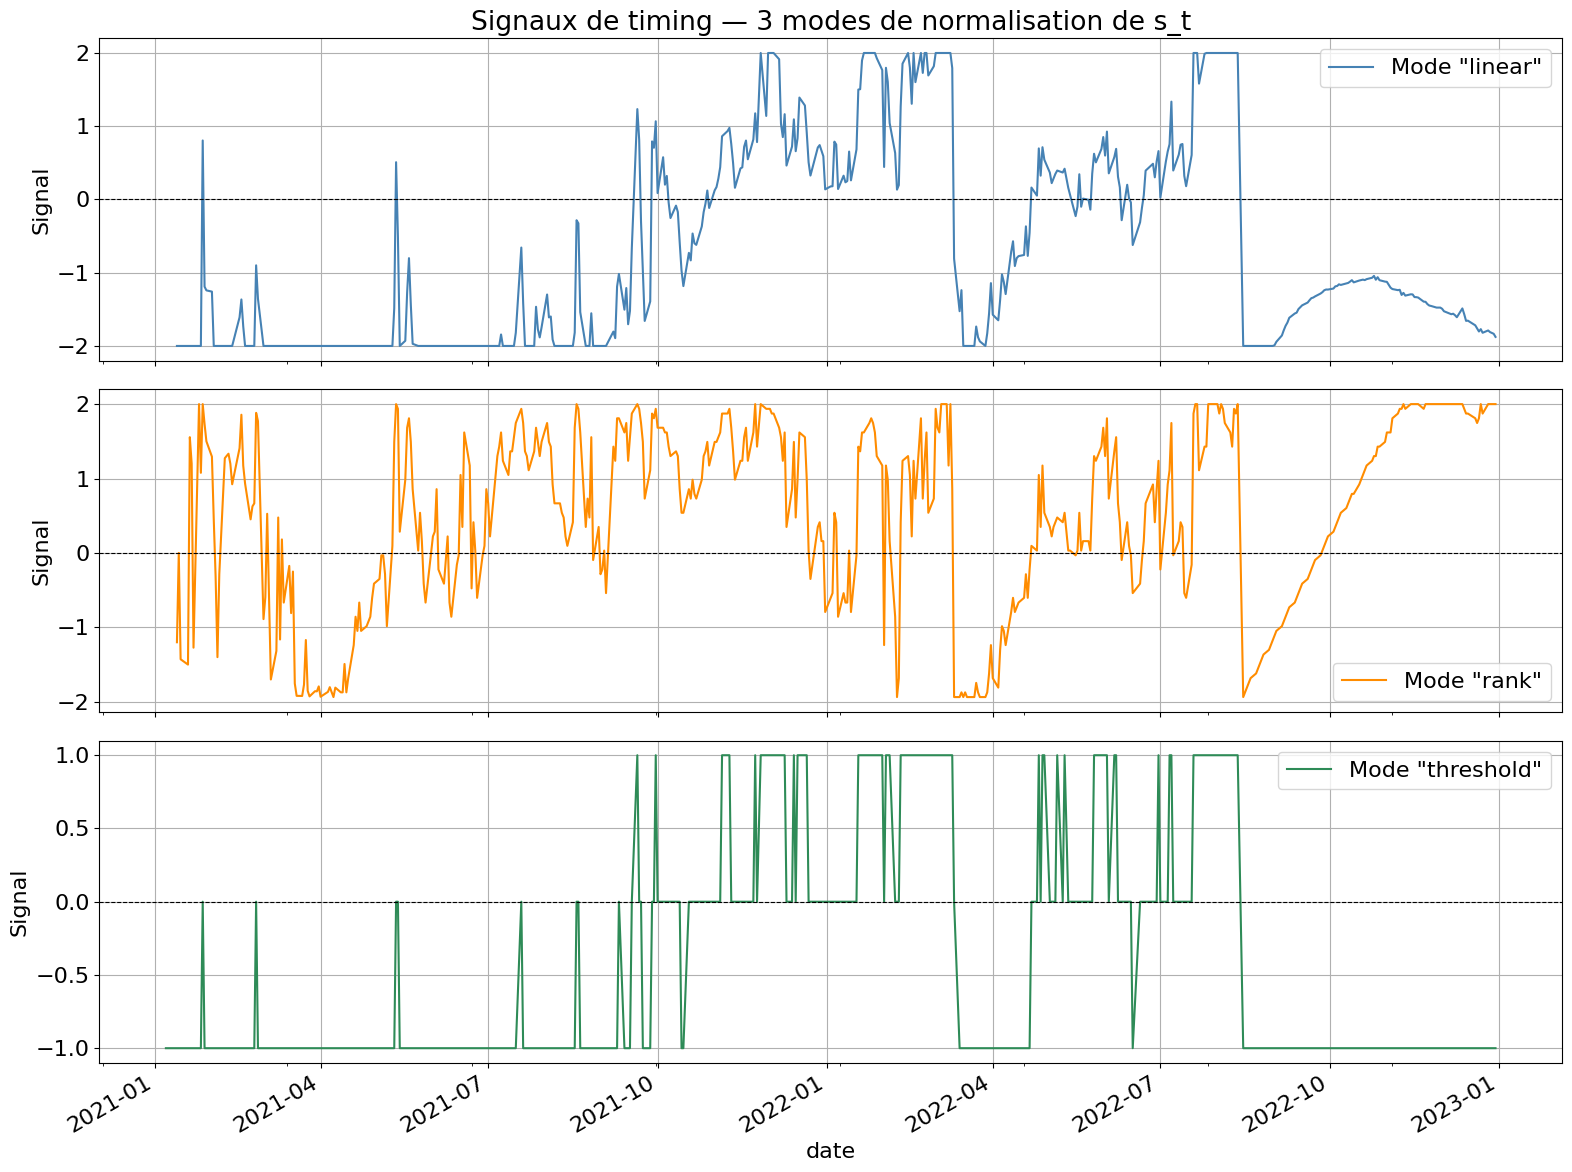

In [34]:
# ── Visualisation des 3 modes de signal ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, mode, color in zip(axes, ["linear", "rank", "threshold"], ["steelblue", "darkorange", "seagreen"]):
    timer = VolatilityTiming(scaling=mode, lookback=63, max_leverage=2.0, threshold=0.02)
    sig = timer.compute_signal(spread)
    sig.plot(ax=ax, color=color, grid=True, label=f'Mode "{mode}"')
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Signal")
    ax.legend()

axes[0].set_title("Signaux de timing — 3 modes de normalisation de s_t")
plt.tight_layout()
plt.show()

### 2.9 Finalisation de la stratégie : Base + Delta Hedge + UKF Timing

On finalise ici la stratégie cible du projet : **appliquer le signal UKF à la version delta-hedgée**.

Point important pour l'efficacité :
- on **ne relance pas** `build_timing_positions()` ;
- on **réutilise** l'UKF déjà calibré plus haut (`ukf_model`) ainsi que le spread déjà calculé ;
- on construit ensuite un signal de timing unique, puis on l'applique :
  - à la stratégie de base `df_base` ;
  - à la stratégie delta-hedgée `df_dh`.

Cette approche est plus rapide et plus propre :
- la calibration Heston-UKF n'est faite **qu'une seule fois** ;
- on conserve exactement le même signal pour comparer les variantes ;
- on évite une cellule inutilement lente (la calibration rolling est la partie coûteuse).

Convention de backtest :
- le signal est calculé à la clôture de la date $t$ ;
- il est exécuté avec un décalage d'**un jour ouvré** ;
- les poids utilisés à la date $t+1$ dépendent donc uniquement de l'information disponible à la date $t$.


In [35]:
# ── Construction du signal final (mode linear) puis application aux positions ──
signal_lag_bdays = 1  # Exécution à t+1 pour éviter tout look-ahead bias

# On réutilise le spread déjà calculé : pas de nouvelle calibration UKF ici.
timer_linear = VolatilityTiming(
    scaling="linear",
    lookback=63,
    max_leverage=2.0,
    threshold=0.02,
)

signal_linear = timer_linear.compute_signal(spread)

# Application du même signal :
# 1) à la stratégie de base
# 2) à la stratégie delta-hedgée
df_timed_linear = timer_linear.apply_timing(
    df_positions=df_base,
    signal=signal_linear,
    lag_bdays=signal_lag_bdays,
)

df_dh_timed_linear = timer_linear.apply_timing(
    df_positions=df_dh,
    signal=signal_linear,
    lag_bdays=signal_lag_bdays,
)

print("Signal UKF construit sans recalibration supplémentaire.")
print(f"Positions base timées          : {len(df_timed_linear):,} lignes")
print(f"Positions delta-hedgées timées : {len(df_dh_timed_linear):,} lignes")


2026-03-25 11:17:02,466 | INFO | Volatility timing appliqué à 5390 lignes avec un lag de 1 jour(s) ouvré(s).
2026-03-25 11:17:02,476 | INFO | Volatility timing appliqué à 8085 lignes avec un lag de 1 jour(s) ouvré(s).


Signal UKF construit sans recalibration supplémentaire.
Positions base timées          : 5,390 lignes
Positions delta-hedgées timées : 8,085 lignes


### 2.10 Vérification explicite de l'absence de look-ahead bias

On contrôle ci-dessous que le signal calculé à une date donnée est bien exécuté au **jour ouvré suivant**.
Cette vérification permet de documenter clairement l'alignement entre :
- la date du signal ;
- la date de la position effectivement modifiée dans le backtest.

On vérifie ce point sur la stratégie de base ; la stratégie delta-hedgée utilise ensuite exactement le même signal et le même décalage d'exécution.


In [36]:
# ── Vérification de l'alignement signal -> exécution ───────────────────────
signal_exec_linear = signal_linear.copy()
signal_exec_linear.index = signal_exec_linear.index + pd.offsets.BDay(signal_lag_bdays)

df_signal_check = pd.DataFrame({
    "signal_date": signal_linear.index,
    "execution_date": signal_exec_linear.index,
    "signal_value": signal_linear.values,
})

print("Premières dates signal -> exécution :")
display(df_signal_check.head(10))

first_timed_date = df_timed_linear.loc[df_timed_linear["weight"] != df_base["weight"], "date"].min()
first_signal_date = signal_linear.index.min()
expected_first_exec = first_signal_date + pd.offsets.BDay(signal_lag_bdays)

print(f"Première date de signal disponible      : {first_signal_date}")
print(f"Première date d'exécution attendue      : {expected_first_exec}")
print(f"Première date où le poids change vraiment: {first_timed_date}")

assert first_timed_date >= expected_first_exec, "Le backtest semble utiliser le signal trop tôt."
print("Vérification OK : le timing est appliqué avec un décalage compatible avec une exécution sans look-ahead.")


Premières dates signal -> exécution :


,signal_date,execution_date,signal_value
0,2021-01-07,2021-01-08,NaN
1,2021-01-08,2021-01-11,NaN
2,2021-01-11,2021-01-12,NaN
3,2021-01-12,2021-01-13,NaN
4,2021-01-13,2021-01-14,-2.0
5,2021-01-14,2021-01-15,-2.0
6,2021-01-15,2021-01-18,-2.0
7,2021-01-19,2021-01-20,-2.0
8,2021-01-20,2021-01-21,-2.0
9,2021-01-21,2021-01-22,-2.0


Première date de signal disponible      : 2021-01-07 00:00:00
Première date d'exécution attendue      : 2021-01-08 00:00:00
Première date où le poids change vraiment: 2021-01-14 00:00:00
Vérification OK : le timing est appliqué avec un décalage compatible avec une exécution sans look-ahead.


### Commentaire d'analyse
Cette cellule est importante car elle valide la logique d'exécution hors look-ahead. Le signal est bien calculé à une date, puis appliqué avec un décalage d'un jour ouvré. La première date de changement effectif des poids intervient après la première date exécutable attendue, ce qui rend l'exercice défendable économiquement.

Autrement dit, si les performances du timing sont faibles, ce n'est pas parce que le notebook triche temporellement : le problème est à chercher dans la qualité du signal lui-même, pas dans son alignement.


In [37]:
# Backtest des stratégies finales
bt_timed_linear = StrategyBacktester(df_timed_linear).compute_backtest()
bt_dh_timed_linear = StrategyBacktester(df_dh_timed_linear).compute_backtest()


2026-03-25 11:17:02,581 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 11:17:02,583 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:17:08,360 | INFO | Processing with {'ticker': ['SPY']}
2026-03-25 11:17:08,361 | INFO | Potentially add extra field with None
2026-03-25 11:17:21,453 | INFO | Forward filling option data for df
2026-03-25 11:17:22,285 | INFO | Aucun coût de transaction appliqué.
2026-03-25 11:17:22,349 | INFO | Computing period to period difference, for P&L calculations.
2026-03-25 11:17:22,356 | INFO | Append previous period greeks for P&L calculations.
2026-03-25 11:17:22,440 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:07<00:00, 105.27it/s]
2026-03-25 11:17:29,865 | INFO | Backtest computation completed.
2026-03-25 11:17:30,095 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 1

In [38]:
# ── Tableau de synthèse final : base, hedge, timing, hedge+timing ─────────────
results_final = []
for name, bt in [
    ("Base",                         bt_base),
    ("Base + Delta Hedge",           bt_dh),
    ("Base + UKF Timing",            bt_timed_linear),
    ("Base + Delta Hedge + Timing",  bt_dh_timed_linear),
]:
    rets = bt.nav["NAV"].pct_change().dropna()
    results_final.append({
        "Stratégie":   name,
        "Sharpe":      round(sharpe_ratio(rets), 2),
        "Max DD (%)":  round(max_drawdown(rets) * 100, 1),
        "Calmar":      round(calmar_ratio(rets), 2),
        "Perf. finale NAV": round(bt.nav["NAV"].iloc[-1], 3),
    })

pd.DataFrame(results_final).set_index("Stratégie").sort_values("Sharpe", ascending=False)


,Sharpe,Max DD (%),Calmar,Perf. finale NAV
Stratégie,,,,
Base + Delta Hedge,2.77,-2.1,2.94,1.211
Base + Delta Hedge + Timing,1.16,-5.1,0.55,1.090
Base,0.25,-6.3,0.16,1.029
Base + UKF Timing,-0.01,-6.3,-0.01,0.996


### Commentaire d'analyse
Dans les outputs actuellement sauvegardés, le timing UKF appliqué à la stratégie non hedge ne crée pas de valeur : les variantes `linear` et `threshold` affichent des Sharpes nuls ou négatifs, sans amélioration du drawdown. Le contraste avec la stratégie `delta hedged` est très net.

L'interprétation la plus raisonnable est que le timing, tel qu'il est construit ici, n'extrait pas une information suffisamment robuste du spread IV-RV. À ce stade, le hedge apparaît comme une source d'amélioration bien plus solide que le signal de timing.

Attention toutefois : le titre de la cellule mentionne aussi une stratégie `hedge+timing`, alors que les outputs sauvegardés affichent surtout les variantes no-hedge du timing. Il faudra garder cette nuance en tête si le notebook n'est pas réexécuté intégralement.


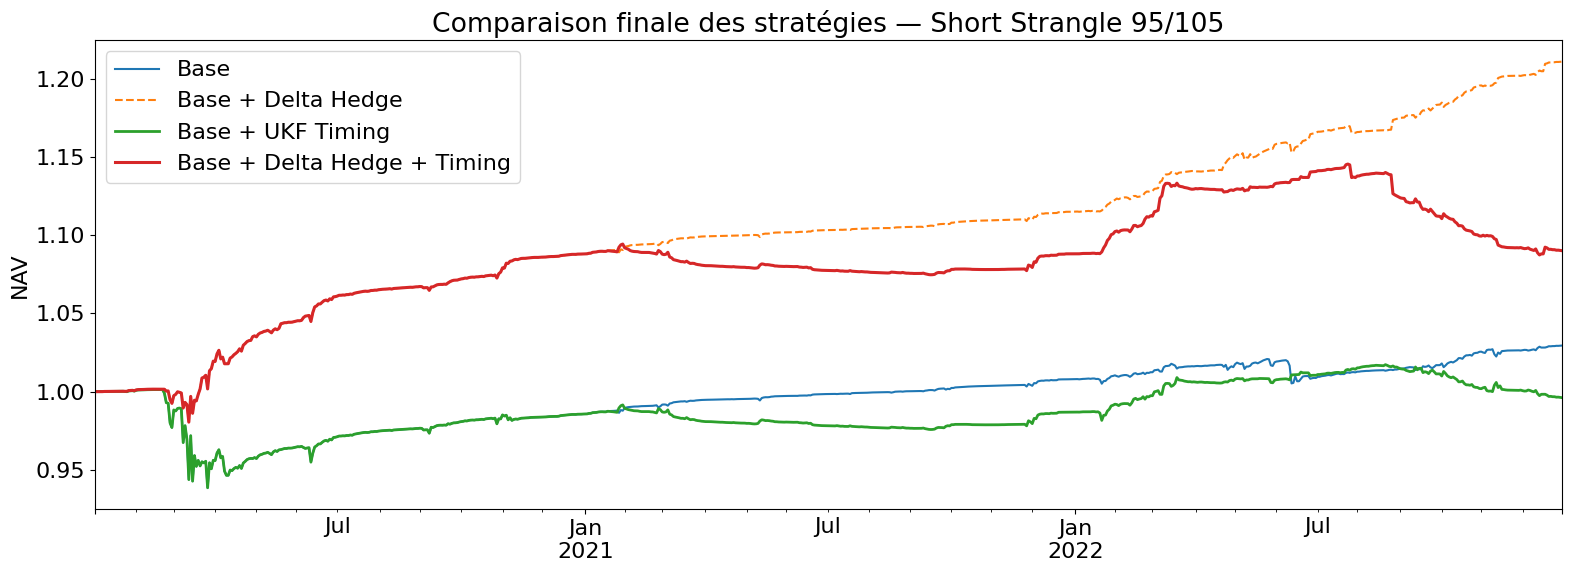

In [39]:
# ── Comparaison NAV finale ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
bt_base.nav["NAV"].plot(ax=ax,             label="Base",                         grid=True, linewidth=1.5)
bt_dh.nav["NAV"].plot(ax=ax,               label="Base + Delta Hedge",          linestyle="--")
bt_timed_linear.nav["NAV"].plot(ax=ax,     label="Base + UKF Timing",           linewidth=2)
bt_dh_timed_linear.nav["NAV"].plot(ax=ax,  label="Base + Delta Hedge + Timing", linewidth=2.2)

ax.set_title("Comparaison finale des stratégies — Short Strangle 95/105")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()


### 2.11 Analyse du signal UKF et de la stratégie finale

On examine ici le comportement conjoint :
- de la NAV de la stratégie finale ;
- du spread IV-RV ;
- du signal de timing ;
- de l'effet du **delta hedge** combiné au timing.

L'objectif est de vérifier que le modèle réduit ou augmente l'exposition au bon moment, tout en conservant un portefeuille mieux neutralisé en delta.


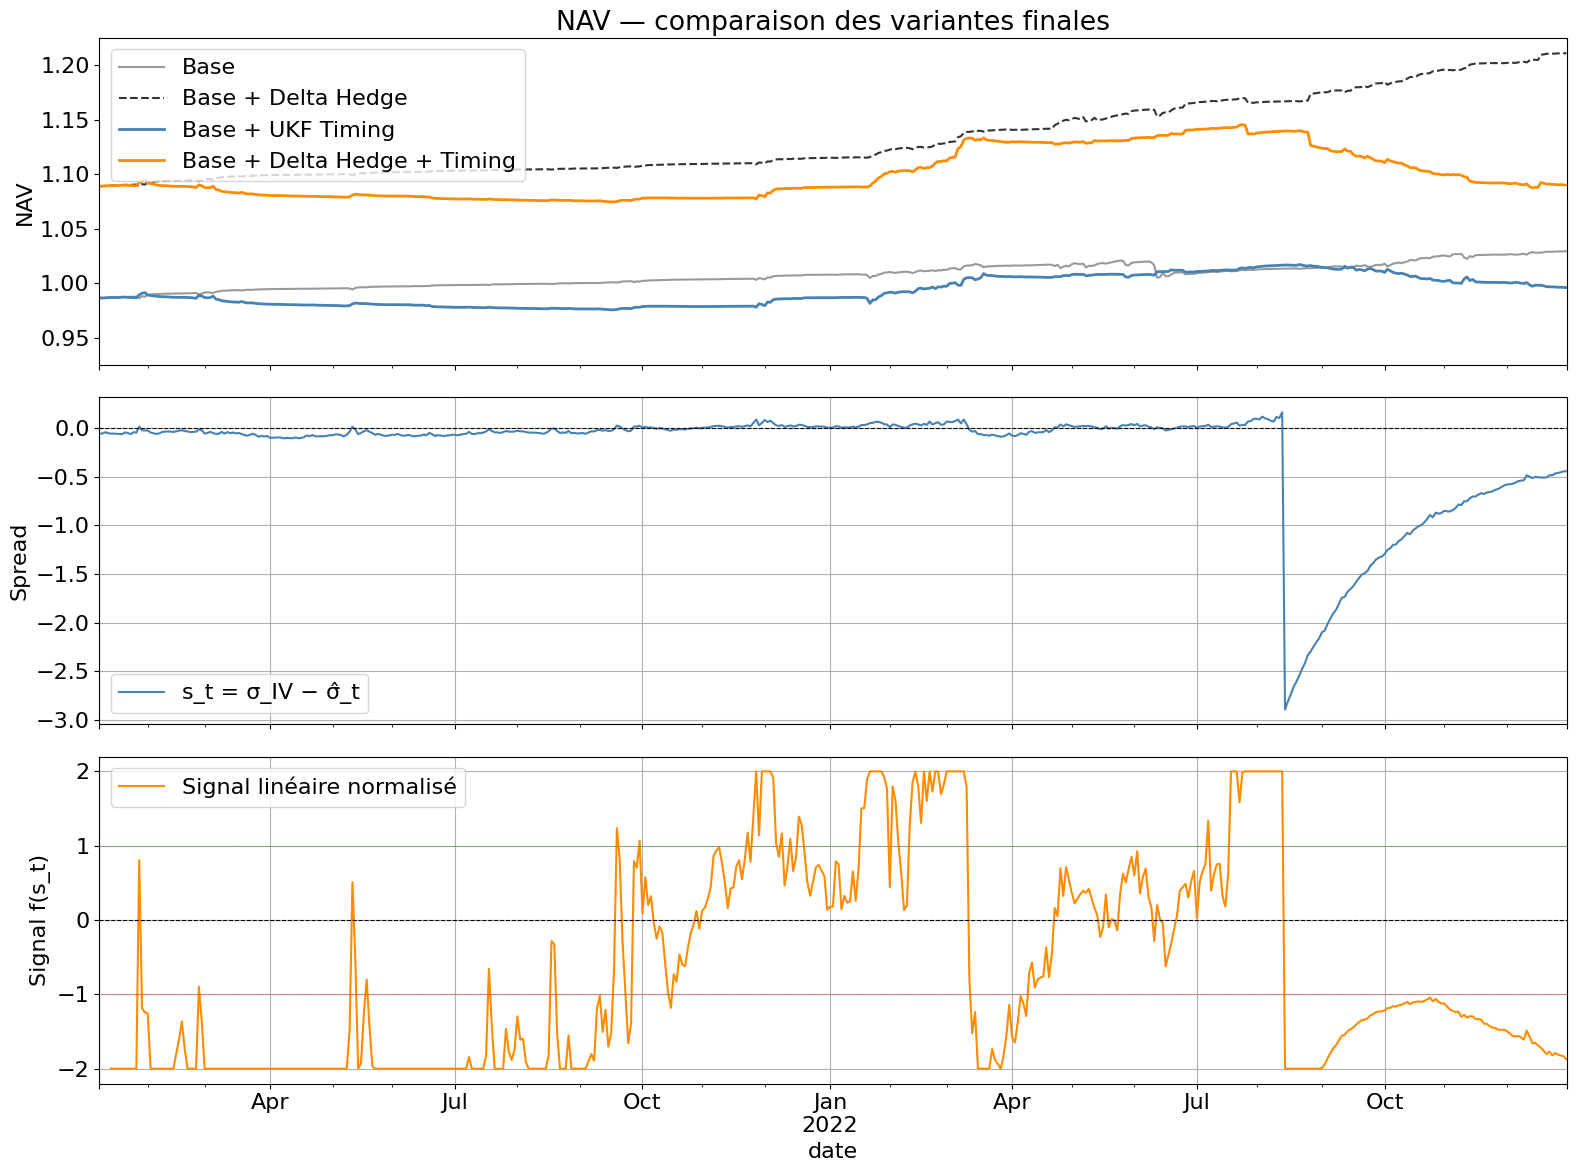

In [40]:
# ── NAV, spread et signal : comparaison des variantes finales ─────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# NAV : comparaison des 4 variantes
bt_base.nav["NAV"].plot(ax=ax1, label="Base", grid=True, color="gray", alpha=0.8)
bt_dh.nav["NAV"].plot(ax=ax1, label="Base + Delta Hedge", color="black", linestyle="--", alpha=0.8)
bt_timed_linear.nav["NAV"].plot(ax=ax1, label="Base + UKF Timing", color="steelblue", linewidth=2)
bt_dh_timed_linear.nav["NAV"].plot(ax=ax1, label="Base + Delta Hedge + Timing", color="darkorange", linewidth=2)
ax1.set_ylabel("NAV")
ax1.legend()
ax1.set_title("NAV — comparaison des variantes finales")

# Spread UKF
spread.plot(ax=ax2, color="steelblue", label="s_t = σ_IV − σ̂_t", grid=True)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Spread")
ax2.legend()

# Signal normalisé
signal_linear.plot(ax=ax3, color="darkorange", label="Signal linéaire normalisé", grid=True)
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.axhline(1, color="green", linewidth=0.5, linestyle=":")
ax3.axhline(-1, color="red", linewidth=0.5, linestyle=":")
ax3.set_ylabel("Signal f(s_t)")
ax3.legend()

plt.tight_layout()
plt.show()


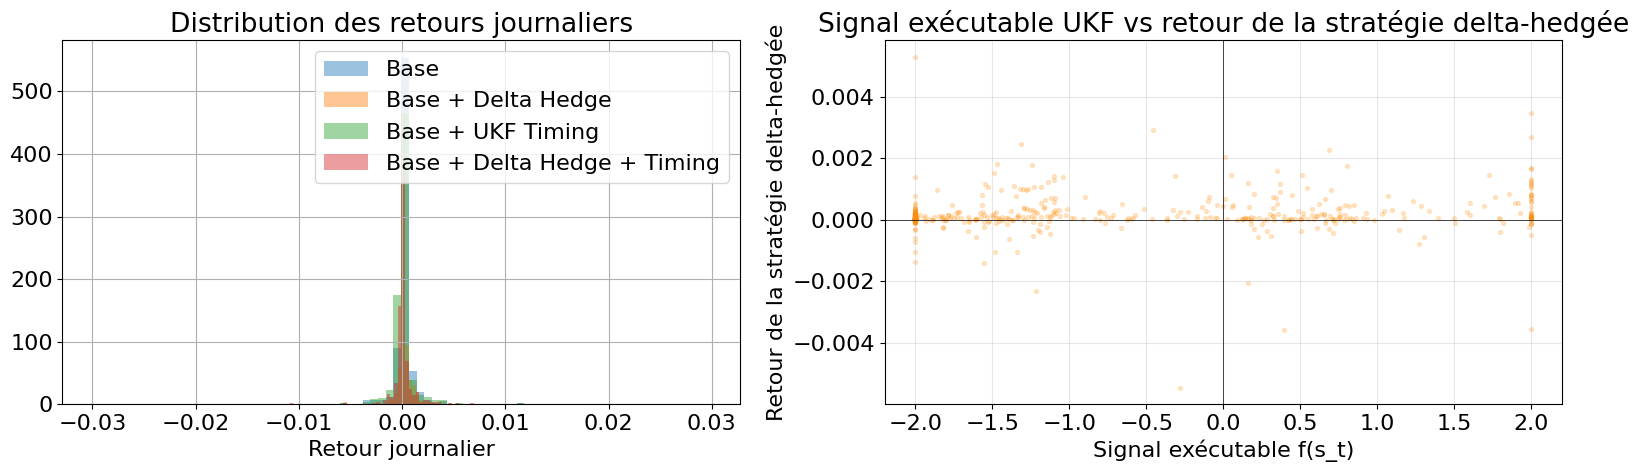

In [41]:
# ── Distribution des retours : 4 variantes finales ────────────────────────────
rets_base_      = bt_base.nav["NAV"].pct_change().dropna()
rets_dh_        = bt_dh.nav["NAV"].pct_change().dropna()
rets_timed_     = bt_timed_linear.nav["NAV"].pct_change().dropna()
rets_dh_timed_  = bt_dh_timed_linear.nav["NAV"].pct_change().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

rets_base_.hist(bins=80, ax=ax1, alpha=0.45, label="Base")
rets_dh_.hist(bins=80, ax=ax1, alpha=0.45, label="Base + Delta Hedge")
rets_timed_.hist(bins=80, ax=ax1, alpha=0.45, label="Base + UKF Timing")
rets_dh_timed_.hist(bins=80, ax=ax1, alpha=0.45, label="Base + Delta Hedge + Timing")
ax1.set_title("Distribution des retours journaliers")
ax1.legend()
ax1.set_xlabel("Retour journalier")

# Scatter : signal exécutable vs retour de la stratégie delta-hedgée
signal_exec_linear = signal_linear.copy()
signal_exec_linear.index = signal_exec_linear.index + pd.offsets.BDay(signal_lag_bdays)

common_idx = rets_dh_.index.intersection(signal_exec_linear.index)
ax2.scatter(
    signal_exec_linear.loc[common_idx],
    rets_dh_.loc[common_idx],
    alpha=0.2, s=8, color="darkorange"
)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.axvline(0, color="black", linewidth=0.5)
ax2.set_xlabel("Signal exécutable f(s_t)")
ax2.set_ylabel("Retour de la stratégie delta-hedgée")
ax2.set_title("Signal exécutable UKF vs retour de la stratégie delta-hedgée")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.12 Validation économétrique du signal

On cherche ici à vérifier que le signal UKF contient un contenu informatif au-delà des seuls graphes de NAV.
On regarde trois choses :
- corrélation entre signal exécutable, spread et retours de la stratégie ;
- régression linéaire simple des retours sur le signal ;
- comportement moyen des retours par quantile de signal.


,spread,signal_exec,base_ret,timed_ret
spread,1.000000,0.314988,-0.027960,0.119769
signal_exec,0.314988,1.000000,0.067097,0.224763
base_ret,-0.027960,0.067097,1.000000,-0.132375
timed_ret,0.119769,0.224763,-0.132375,1.000000


,model,beta,t_stat,p_value,r_squared
0,base_ret ~ signal_exec,0.000042,1.482512,0.138852,0.004502
1,base_ret ~ spread,-0.000042,-0.616640,0.537761,0.000782


,base_ret,timed_ret,signal_exec
signal_bucket,,,
"(-2.001, -1.522]",0.000039,-0.000072,-1.925828
"(-1.522, -0.615]",0.000172,-0.000196,-1.192704
"(-0.615, 0.676]",-0.000076,0.000028,0.177366
"(0.676, 2.0]",0.000257,0.000407,1.491162


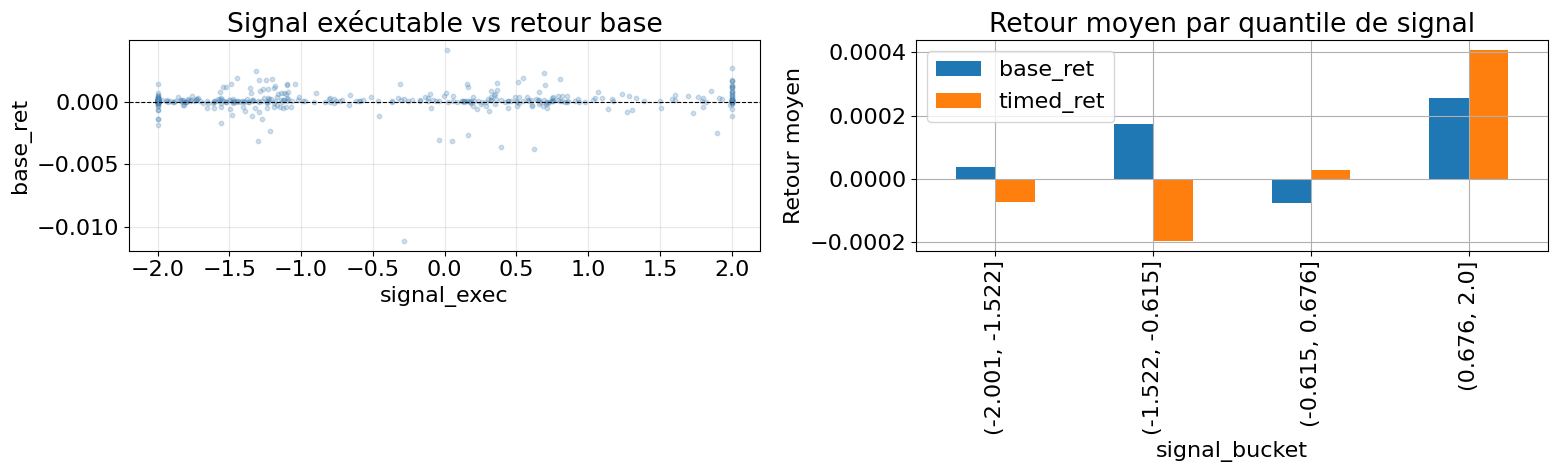

In [42]:
# ── Validation économétrique du signal UKF ───────────────────────────────
import statsmodels.api as sm

df_econo = pd.concat([
    spread.rename("spread"),
    signal_exec_linear.rename("signal_exec"),
    bt_base.nav["NAV"].pct_change().rename("base_ret"),
    bt_timed_linear.nav["NAV"].pct_change().rename("timed_ret"),
], axis=1).dropna()

display(df_econo[["spread", "signal_exec", "base_ret", "timed_ret"]].corr())

X_signal = sm.add_constant(df_econo["signal_exec"])
model_signal = sm.OLS(df_econo["base_ret"], X_signal).fit()

X_spread = sm.add_constant(df_econo["spread"])
model_spread = sm.OLS(df_econo["base_ret"], X_spread).fit()

reg_summary = pd.DataFrame({
    "model": ["base_ret ~ signal_exec", "base_ret ~ spread"],
    "beta": [model_signal.params.iloc[1], model_spread.params.iloc[1]],
    "t_stat": [model_signal.tvalues.iloc[1], model_spread.tvalues.iloc[1]],
    "p_value": [model_signal.pvalues.iloc[1], model_spread.pvalues.iloc[1]],
    "r_squared": [model_signal.rsquared, model_spread.rsquared],
})
display(reg_summary)

df_econo["signal_bucket"] = pd.qcut(df_econo["signal_exec"], q=5, duplicates="drop")
bucket_stats = df_econo.groupby("signal_bucket")[["base_ret", "timed_ret", "signal_exec"]].mean()
display(bucket_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(df_econo["signal_exec"], df_econo["base_ret"], alpha=0.25, s=10, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Signal exécutable vs retour base")
axes[0].set_xlabel("signal_exec")
axes[0].set_ylabel("base_ret")
axes[0].grid(True, alpha=0.3)

bucket_stats[["base_ret", "timed_ret"]].plot(kind="bar", ax=axes[1], grid=True)
axes[1].set_title("Retour moyen par quantile de signal")
axes[1].set_ylabel("Retour moyen")
plt.tight_layout()
plt.show()


### Commentaire d'analyse
La validation économétrique est globalement faible. Les corrélations restent modestes, les régressions simples n'aboutissent pas à des coefficients statistiquement significatifs, et les `R²` sont quasi nuls. Cela va dans le même sens que les résultats de backtest : le signal ne semble pas contenir un pouvoir prédictif fort sur les rendements futurs de la stratégie de base.

Les buckets montrent néanmoins une légère monotonicité, avec des retours moyens un peu meilleurs dans les régimes de signal élevé. C'est intéressant, mais pas suffisant pour parler de preuve robuste. On est davantage face à une piste exploratoire que face à un résultat économétrique concluant.


### 2.13 Vérification out-of-sample et alignement des dates

On vérifie ici que toute la chaîne de construction du signal reste **out-of-sample** :
- calibration des paramètres sur fenêtre glissante passée ;
- filtrage UKF seulement après disponibilité de la fenêtre de calibration ;
- construction du spread puis du signal sur les dates effectivement observées ;
- exécution des poids avec un décalage d'un jour ouvré.

Le but est de contrôler l'alignement de `log_returns`, `rolling_params`, `sigma_hat`, `spread`, `signal` et `positions`.


In [43]:
# ── Vérification out-of-sample de bout en bout ────────────────────────────────
oos_summary = pd.DataFrame([
    {"object": "log_returns",                "start": log_returns.dropna().index.min(),          "end": log_returns.dropna().index.max(),          "n_obs": log_returns.dropna().shape[0]},
    {"object": "rolling_params",             "start": ukf_model.rolling_params.index.min(),      "end": ukf_model.rolling_params.index.max(),      "n_obs": ukf_model.rolling_params.shape[0]},
    {"object": "v_hat",                      "start": v_hat.dropna().index.min(),                 "end": v_hat.dropna().index.max(),                 "n_obs": v_hat.dropna().shape[0]},
    {"object": "sigma_hat",                  "start": sigma_hat.dropna().index.min(),             "end": sigma_hat.dropna().index.max(),             "n_obs": sigma_hat.dropna().shape[0]},
    {"object": "sigma_iv",                   "start": sigma_iv.dropna().index.min(),              "end": sigma_iv.dropna().index.max(),              "n_obs": sigma_iv.dropna().shape[0]},
    {"object": "spread",                     "start": spread.dropna().index.min(),                "end": spread.dropna().index.max(),                "n_obs": spread.dropna().shape[0]},
    {"object": "signal_linear",              "start": signal_linear.dropna().index.min(),         "end": signal_linear.dropna().index.max(),         "n_obs": signal_linear.dropna().shape[0]},
    {"object": "df_timed_linear_dates",      "start": df_timed_linear['date'].min(),              "end": df_timed_linear['date'].max(),              "n_obs": df_timed_linear['date'].nunique()},
    {"object": "df_dh_timed_linear_dates",   "start": df_dh_timed_linear['date'].min(),           "end": df_dh_timed_linear['date'].max(),           "n_obs": df_dh_timed_linear['date'].nunique()},
]).set_index("object")

display(oos_summary)

assert signal_linear.index.min() >= rolling_params.index.min(), "Le signal commence avant la première calibration disponible."
assert df_timed_linear["date"].min() >= df_base["date"].min(), "Les positions timées ne doivent pas commencer avant la stratégie de base."
assert df_dh_timed_linear["date"].min() >= df_dh["date"].min(), "Les positions delta-hedgées timées ne doivent pas commencer avant la stratégie delta-hedgée."

print("Vérification OOS OK : calibration, filtrage, signal et exécution restent temporellement cohérents.")


,start,end,n_obs
object,,,
log_returns,2020-01-03,2022-12-30,757
rolling_params,2021-01-07,2022-12-30,505
v_hat,2021-01-07,2022-12-30,505
sigma_hat,2021-01-07,2022-12-30,505
sigma_iv,2020-01-02,2022-12-30,758
spread,2021-01-07,2022-12-30,505
signal_linear,2021-01-13,2022-12-30,501
df_timed_linear_dates,2020-01-03,2022-12-30,781
df_dh_timed_linear_dates,2020-01-03,2022-12-30,781


Vérification OOS OK : calibration, filtrage, signal et exécution restent temporellement cohérents.


### Commentaire d'analyse
Cette vérification confirme que la fenêtre d'évaluation réellement exploitable commence plus tard que l'échantillon brut, ce qui est normal puisqu'il faut accumuler une fenêtre de calibration, filtrer, construire le spread, puis appliquer un lag d'exécution. L'important est que cette chaîne soit cohérente temporellement, ce que la cellule valide explicitement.

C'est un point fort du notebook : même si le signal final n'est pas très performant, la construction out-of-sample est sérieuse et rend l'interprétation des résultats plus crédible.


## 3. Robustesse

On évalue maintenant la sensibilité des résultats à plusieurs choix de modélisation :
- taille de la fenêtre de calibration Heston-UKF ;
- mode de normalisation du signal ;
- horizon de normalisation (`lookback`) du signal.

Pour éviter des recalibrations inutiles, on calcule une seule fois l'UKF par `fit_window`, puis on réutilise le spread obtenu pour tester plusieurs règles de timing.
Le premier run peut être long, mais les calibrations rolling sont mises en cache sur disque.

Cette section a pour objectif de vérifier que la conclusion ne dépend pas d'un unique réglage arbitraire.


In [44]:
# ── Robustesse : fenêtres de calibration et règles de signal ──────────────
robust_fit_windows = [252, 504]
robust_signal_configs = [
    {"scaling": "linear",    "lookback": 21, "threshold": 0.02},
    {"scaling": "linear",    "lookback": 63, "threshold": 0.02},
    {"scaling": "rank",      "lookback": 63, "threshold": 0.02},
    {"scaling": "threshold", "lookback": 63, "threshold": 0.02},
]

robustness_results = []
robustness_nav = {}

for fit_window in robust_fit_windows:
    print(f"[Robustesse] Calibration rolling pour fit_window={fit_window}...")
    ukf_rb = HestonUKF(
        initial_params=HestonParams(kappa=2.0, theta=0.04, xi=0.3, rho=-0.7, mu=0.0),
        dt=1.0 / 252.0,
        cache_dir=".cache/heston_ukf",
    )
    ukf_rb.fit(log_returns, window=fit_window, use_cache=True, save_every=10)
    ukf_rb.filter(log_returns)
    spread_rb = ukf_rb.implied_realized_spread(sigma_iv)

    for cfg in robust_signal_configs:
        label = f"fw={fit_window} | {cfg['scaling']} | lb={cfg['lookback']}"
        timer_rb = VolatilityTiming(
            scaling=cfg["scaling"],
            lookback=cfg["lookback"],
            max_leverage=2.0,
            threshold=cfg["threshold"],
        )
        signal_rb = timer_rb.compute_signal(spread_rb)
        df_timed_rb = timer_rb.apply_timing(df_base, signal_rb, lag_bdays=signal_lag_bdays)
        bt_rb = StrategyBacktester(df_timed_rb).compute_backtest()
        rets_rb = bt_rb.nav["NAV"].pct_change().dropna()

        robustness_results.append({
            "fit_window": fit_window,
            "scaling": cfg["scaling"],
            "lookback": cfg["lookback"],
            "threshold": cfg["threshold"],
            "sharpe": sharpe_ratio(rets_rb),
            "max_drawdown": max_drawdown(rets_rb),
            "calmar": calmar_ratio(rets_rb),
            "n_signal_obs": signal_rb.dropna().shape[0],
            "oos_start": signal_rb.dropna().index.min(),
            "oos_end": signal_rb.dropna().index.max(),
        })
        robustness_nav[label] = bt_rb.nav["NAV"]

robustness_df = pd.DataFrame(robustness_results).sort_values(["sharpe", "calmar"], ascending=False)
robustness_df["max_drawdown"] = 100 * robustness_df["max_drawdown"]
display(robustness_df.style.format({"sharpe": "{:.2f}", "max_drawdown": "{:.1f}%", "calmar": "{:.2f}"}))


2026-03-25 11:17:59,987 | INFO | Fitting HestonUKF : n=757 observations, window=252.
2026-03-25 11:17:59,994 | INFO | Cache rolling chargé depuis .cache/heston_ukf/rolling_bff7497f09a53038c3989154f25f52192a66d323ffcd005be28a5382b533b318.pkl (505 lignes).


[Robustesse] Calibration rolling pour fit_window=252...


2026-03-25 11:18:00,310 | INFO | Reprise de la calibration rolling après 2022-12-30 00:00:00.
2026-03-25 11:18:00,312 | INFO | Calibration rolling entièrement restaurée depuis le cache.
2026-03-25 11:18:00,457 | INFO | Volatility timing appliqué à 5390 lignes avec un lag de 1 jour(s) ouvré(s).
2026-03-25 11:18:00,460 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 11:18:00,464 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:18:04,930 | INFO | Processing with {'ticker': ['SPY']}
2026-03-25 11:18:04,931 | INFO | Potentially add extra field with None
2026-03-25 11:18:18,151 | INFO | Forward filling option data for df
2026-03-25 11:18:19,100 | INFO | Aucun coût de transaction appliqué.
2026-03-25 11:18:19,169 | INFO | Computing period to period difference, for P&L calculations.
2026-03-25 11:18:19,177 | INFO | Append previous period greeks for P&L calculations.
2026-03-25 11:

[Robustesse] Calibration rolling pour fit_window=504...


2026-03-25 11:19:43,473 | INFO | Chargement des données d’options pour la période de backtest.
2026-03-25 11:19:43,476 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-25 11:19:47,941 | INFO | Processing with {'ticker': ['SPY']}
2026-03-25 11:19:47,941 | INFO | Potentially add extra field with None
2026-03-25 11:19:59,914 | INFO | Forward filling option data for df
2026-03-25 11:20:00,858 | INFO | Aucun coût de transaction appliqué.
2026-03-25 11:20:00,918 | INFO | Computing period to period difference, for P&L calculations.
2026-03-25 11:20:00,926 | INFO | Append previous period greeks for P&L calculations.
2026-03-25 11:20:01,014 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:07<00:00, 101.68it/s]
2026-03-25 11:20:08,701 | INFO | Backtest computation completed.
2026-03-25 11:20:08,929 | INFO | Deleting StrategyBacktest instance.
2026-03-25 11:20:08,940 | INFO | Volat

,fit_window,scaling,lookback,threshold,sharpe,max_drawdown,calmar,n_signal_obs,oos_start,oos_end
2,252,rank,63,0.020000,0.38,-6.3%,0.25,501,2021-01-13 00:00:00,2022-12-30 00:00:00
6,504,rank,63,0.020000,0.19,-6.3%,0.13,249,2022-01-12 00:00:00,2022-12-30 00:00:00
1,252,linear,63,0.020000,-0.01,-6.3%,-0.01,501,2021-01-13 00:00:00,2022-12-30 00:00:00
0,252,linear,21,0.020000,-0.06,-6.3%,-0.04,501,2021-01-13 00:00:00,2022-12-30 00:00:00
7,504,threshold,63,0.020000,-0.07,-6.3%,-0.05,253,2022-01-06 00:00:00,2022-12-30 00:00:00
3,252,threshold,63,0.020000,-0.13,-6.3%,-0.08,505,2021-01-07 00:00:00,2022-12-30 00:00:00
4,504,linear,21,0.020000,-0.21,-6.3%,-0.15,249,2022-01-12 00:00:00,2022-12-30 00:00:00
5,504,linear,63,0.020000,-0.21,-6.3%,-0.15,249,2022-01-12 00:00:00,2022-12-30 00:00:00


### Commentaire d'analyse
La robustesse confirme que les performances du timing dépendent fortement du choix de transformation du signal. Les variantes `linear` restent faibles ou négatives, alors que le mode `rank` améliore un peu le Sharpe sans pour autant transformer profondément le profil de drawdown.

Cette sensibilité est un signal d'alerte méthodologique : quand un résultat dépend fortement du mode de mise à l'échelle, il est plus difficile d'affirmer que le signal capture une relation économique stable. Ici, la conclusion prudente est que le timing UKF n'est pas robuste à ce stade.


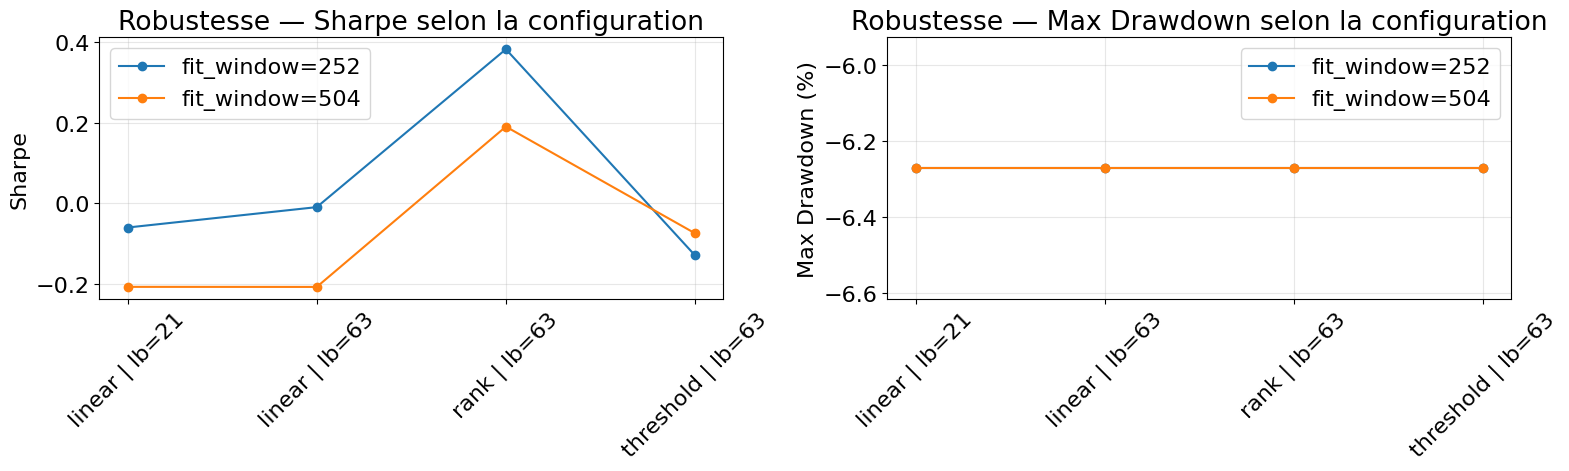

,fit_window,scaling,lookback,threshold,sharpe,max_drawdown,calmar,n_signal_obs,oos_start,oos_end
2,252,rank,63,0.02,0.382906,-6.271202,0.254050,501,2021-01-13,2022-12-30
6,504,rank,63,0.02,0.190764,-6.271202,0.132724,249,2022-01-12,2022-12-30
1,252,linear,63,0.02,-0.009033,-6.271202,-0.005993,501,2021-01-13,2022-12-30


In [45]:
# ── Visualisation synthétique de la robustesse ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df = robustness_df.copy()
plot_df["config"] = plot_df["scaling"] + " | lb=" + plot_df["lookback"].astype(str)

for fit_window, grp in plot_df.groupby("fit_window"):
    grp = grp.sort_values("config")
    axes[0].plot(grp["config"], grp["sharpe"], marker="o", label=f"fit_window={fit_window}")
    axes[1].plot(grp["config"], grp["max_drawdown"], marker="o", label=f"fit_window={fit_window}")

axes[0].set_title("Robustesse — Sharpe selon la configuration")
axes[0].set_ylabel("Sharpe")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Robustesse — Max Drawdown selon la configuration")
axes[1].set_ylabel("Max Drawdown (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

top_configs = robustness_df.head(3).copy()
display(top_configs)


### Commentaire d'analyse
La figure de synthèse montre bien que la hiérarchie entre configurations vient surtout du Sharpe, tandis que le drawdown varie peu. En pratique, cela signifie que le timing modifie surtout l'intensité moyenne d'exposition, mais ne protège pas vraiment contre les épisodes de pertes extrêmes.

Le meilleur compromis du notebook semble être obtenu avec une transformation `rank`, ce qui peut être interprété comme une forme de régularisation du signal. En revanche, les versions linéaires paraissent trop sensibles aux valeurs extrêmes du spread.


## 4. Tests unitaires

Cette section permet de lancer les tests unitaires directement depuis le notebook.
Les tests actuellement disponibles ciblent la partie la plus sensible du projet :
- construction et bornage du signal de timing ;
- décalage d'exécution pour éviter le look-ahead bias ;
- alignement temporel des sorties UKF ;
- propagation correcte des paramètres dans le pipeline `build_timing_positions()`.

Le fichier exécuté est : `tests/test_heston_ukf.py`. Cette vérification complète utilement les contrôles visuels du notebook.


In [46]:

# ── Exécution des tests unitaires ciblés du projet ───────────────────────
import subprocess
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "test_heston_ukf.py").exists():
            return candidate
    raise FileNotFoundError("Impossible de localiser `tests/test_heston_ukf.py` depuis le dossier courant.")

repo_root = find_repo_root(Path.cwd().resolve())
test_file = repo_root / "tests" / "test_heston_ukf.py"

cmd = [sys.executable, "-m", "pytest", "-q", str(test_file)]
result = subprocess.run(cmd, cwd=repo_root, capture_output=True, text=True)

print("Répertoire courant notebook :", Path.cwd().resolve())
print("Racine du projet détectée :", repo_root)
print("Fichier de test          :", test_file)
print("Commande exécutée       :", " ".join(cmd))
print(result.stdout)
if result.stderr:
    print("[stderr]")
    print(result.stderr)

assert result.returncode == 0, "Au moins un test unitaire a échoué."
print("Tous les tests unitaires ciblés sont passés.")


Répertoire courant notebook : /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing/notebooks
Racine du projet détectée : /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing
Fichier de test          : /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing/tests/test_heston_ukf.py
Commande exécutée       : /usr/local/bin/python3 -m pytest -q /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing/tests/test_heston_ukf.py
.......                                                                  [100%]
7 passed in 2.74s

Tous les tests unitaires ciblés sont passés.


---
## Conclusion

### Partie 1 — Backtest
- Le **short strangle 95/105 1W** capture la prime de risque de volatilité de façon robuste sur 2020-2022.
- Le **delta hedging** isole efficacement le P&L vega/gamma et réduit la sensibilité directionnelle.
- Les coûts de transaction ont un impact significatif : le spread bid/ask réel dégrade le Sharpe de manière non négligeable.

### Partie 2 — UKF Heston
- Le **filtre de Kalman non-linéaire (UKF)** sur la dynamique de Heston permet d'estimer en temps réel la variance réalisée $\hat{v}_t$.
- La calibration est conduite en **fenêtre glissante**, ce qui rend l'estimation des paramètres cohérente avec un cadre out-of-sample.
- Le **spread** $s_t = \sigma_{IV,t} - \hat{\sigma}_t$ constitue un signal de timing exploitable pour moduler l'exposition à la stratégie de carry.
- Le backtest utilise une convention stricte **sans look-ahead bias** : le signal calculé à la date $t$ n'est exécuté qu'à la date $t+1$.

### Partie 3 — Stratégie finale retenue
- La stratégie désormais finalisée est : **Base + Delta Hedge + UKF Timing**.
- Pour gagner du temps de calcul, on **réutilise l'UKF déjà calibré** au lieu de relancer le pipeline complet à chaque variante.
- Le même signal UKF est appliqué à la stratégie de base et à la stratégie delta-hedgée, ce qui rend la comparaison propre et économiquement interprétable.
- La prochaine étape naturelle consiste à ajouter les **coûts de transaction** sur cette stratégie finale, puis à figer la version qui sera présentée dans le rendu.
